In [1]:
import infercnvpy as cnv

In [ ]:
import os
import sys
import pickle
import dill
import numpy as np
import pandas as pd
import scipy
from scipy import stats
from scipy.stats import ranksums
# 绘图设置
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.pyplot import rc_context
import seaborn as sns
from statannotations.Annotator import Annotator
# 绘图字体 & 导出配置（论文级）
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['pdf.use14corefonts'] = False
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['font.sans-serif'] = ['Arial']
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.facecolor'] = 'white'
sns.set_style("white")
sns.set_context("paper")
plt.rcParams['axes.grid'] = False
# 单细胞分析
import anndata as ad
import scanpy as sc
import scanpy.external as sce
# 统计模型
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multitest import multipletests
import openpyxl
# Jupyter 专用
from IPython.display import display
from IPython.display import display, Markdown
%matplotlib inline
# 全局参数
os.chdir('/mnt/f/BTC_atlas_投稿/')
np.random.seed(34)
plt.rcParams['figure.figsize'] = [5, 5]
sc.set_figure_params(figsize=(5, 5))
color_clusters = sc.pl.palettes.default_102

In [3]:
os.chdir('/mnt/f/HCC_ICB_project/NC_scRNAseq_dataset/')

# 1. Infercnv

In [4]:
adata = ad.read_h5ad('/mnt/f/HCC_ICB_project/Hotspot/HCC_ICB_atlas_integrated.h5ad') #未注释

In [5]:
cluster2annotation = {
    '0': 'Mesenchymal',
    '1': 'Endothelial',
    '2': 'Myeloid',
    '3': 'Myeloid',
    '4': 'Epithelial',
    '5': 'Mast',
    '6': 'T/NK cells',
    '7': 'T/NK cells',
    '8': 'T/NK cells',
    '9': 'T/NK cells',
    '10': 'T/NK cells',
    '11': 'T/NK cells',
    '12': 'T/NK cells',
    '13': 'T/NK cells',
    '14': 'T/NK cells',
    '15': 'B/plasma',
    '16': 'DCs',
    '18': 'DCs',
    '17': 'B/plasma', 
    '19': 'Epithelial',
}
adata.obs['celltype'] = adata.obs['leiden05'].map(cluster2annotation).astype('category')

In [6]:
adsub = adata[adata.obs['dataset'].isin(['IMBRAVE150']), :].copy() #NC文章

In [9]:
infercnv_ref = adsub[
    adsub.obs["celltype"].isin([
        "T/NK cells",
        "Mesenchymal",
        "Endothelial"
    ])
].copy()

In [10]:
infercnv_ref

AnnData object with n_obs × n_vars = 33954 × 3000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'response', 'treatment', 'condition', 'group', 'dataset', 'sample', 'lesion', 'doublet_score', 'predicted_doublet', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'total_counts_hb', 'pct_counts_hb', 'total_counts_hsp', 'pct_counts_hsp', 'S_score', 'G2M_score', 'phase', 'cc.difference', 'leiden05', 'leiden02', 'Epi_vs_TME', 'celltype'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'cosg', 'hvg', 'leiden02', 'leiden05', 'leiden05_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_pca_original', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'log1p'
    obsp: 'connectivities', 'distances'

In [11]:
print(infercnv_ref.obs['celltype'].value_counts())

celltype
T/NK cells     27016
Endothelial     5000
Mesenchymal     1938
Name: count, dtype: int64


In [ ]:
#infercnv_ref 下采样

In [ ]:
# rng = np.random.default_rng(seed=34)

# # 随机下采样50000个细胞
# if infercnv_ref.n_obs > 50000:
#     idx = rng.choice(infercnv_ref.n_obs, size=50000, replace=False)
#     infercnv_ref = infercnv_ref[idx].copy()

# print(infercnv_ref)

In [12]:
epi = ad.read_h5ad("/mnt/f/HCC_ICB_project/T+A/T+A_hepatocytes.h5ad") #3000HVGs

In [29]:
epi = epi[epi.obs['Treatment'].isin(['atezo+bev','ICP','atezo+cabo']), :].copy()
epi = epi[epi.obs['Response'].isin(['Responder','NonResponder']), :].copy()

In [17]:
infercnv_ref = infercnv_ref.raw.to_adata()
epi = epi.raw.to_adata()
gtf = pd.read_csv("/mnt/d/shared_input/gtf.csv")
gtf.head()
protein_coding_genes = gtf.loc[gtf['gene_biotype'] == 'protein_coding', 'gene_name'].unique()
genes_in_adata = infercnv_ref.var_names
filtered_genes = [gene for gene in genes_in_adata if gene in protein_coding_genes]
infercnv_ref = infercnv_ref[:, filtered_genes].copy()

In [31]:
genes_in_adata = epi.var_names
filtered_genes = [gene for gene in genes_in_adata if gene in protein_coding_genes]
epi = epi[:, filtered_genes].copy()

In [19]:
infercnv_ref

AnnData object with n_obs × n_vars = 33954 × 18838
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'response', 'treatment', 'condition', 'group', 'dataset', 'sample', 'lesion', 'doublet_score', 'predicted_doublet', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'total_counts_hb', 'pct_counts_hb', 'total_counts_hsp', 'pct_counts_hsp', 'S_score', 'G2M_score', 'phase', 'cc.difference', 'leiden05', 'leiden02', 'Epi_vs_TME', 'celltype'
    uns: 'cosg', 'hvg', 'leiden02', 'leiden05', 'leiden05_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_pca_original', 'X_umap'
    obsp: 'connectivities', 'distances'

In [32]:
epi

AnnData object with n_obs × n_vars = 16250 × 18735
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Tumour_ID', 'Patient_ID', 'Response', 'Treatment', 'Week', 'sample', 'doublet_score', 'predicted_doublet', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'total_counts_hb', 'pct_counts_hb', 'total_counts_hsp', 'pct_counts_hsp', 'S_score', 'G2M_score', 'phase', 'cc.difference', 'leiden05', 'leiden02', 'leiden1'
    var: 'features'
    uns: 'cosg', 'hvg', 'leiden02', 'leiden02_colors', 'leiden05', 'leiden1', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_pca_original', 'X_umap'
    obsp: 'connectivities', 'distances'

In [33]:
merged_adata = infercnv_ref.concatenate(epi, batch_key='cnv_batch', index_unique=None)

/tmp/ipykernel_9285/293378136.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  merged_adata = infercnv_ref.concatenate(epi, batch_key='cnv_batch', index_unique=None)


In [21]:
df = pd.read_csv('/mnt/d/shared_input/gene_infor_处理后.csv')

In [34]:
adata = merged_adata.copy()
duplicate_genes = set(adata.var_names) & set(df['gene_ids'])
subset_adata = adata[:, adata.var_names.isin(duplicate_genes)]
subset_df = df[df['gene_ids'].isin(duplicate_genes)]
duplicate_genes2 = set(subset_adata.var_names) & set(subset_df['gene_ids'])
# 检查 'gene' 列是否有重复值
duplicate_genes3 = subset_df[subset_df.duplicated('gene_ids')]
subset_df_unique = subset_df.drop_duplicates(subset='gene_ids', keep='first') #去重复
#加入基因染色体信息
subset_adata.var['chromosome'] = subset_df_unique['chr'].to_list()
subset_adata.var['start'] = subset_df_unique['start'].to_list()
subset_adata.var['end'] = subset_df_unique['end'].to_list()
#去掉NA
subset_adata = subset_adata[: , subset_adata.var.chromosome.notna()]
#再检查基因信息 染色体和基因位置
subset_adata.var
merged_adata = subset_adata.copy()

/tmp/ipykernel_9285/495006523.py:10: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  subset_adata.var['chromosome'] = subset_df_unique['chr'].to_list()


In [36]:
merged_adata

AnnData object with n_obs × n_vars = 50204 × 17908
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'response', 'treatment', 'condition', 'group', 'dataset', 'sample', 'lesion', 'doublet_score', 'predicted_doublet', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'total_counts_hb', 'pct_counts_hb', 'total_counts_hsp', 'pct_counts_hsp', 'S_score', 'G2M_score', 'phase', 'cc.difference', 'leiden05', 'leiden02', 'Epi_vs_TME', 'celltype', 'Tumour_ID', 'Patient_ID', 'Response', 'Treatment', 'Week', 'leiden1', 'cnv_batch'
    var: 'features-1', 'chromosome', 'start', 'end'
    obsm: 'X_pca', 'X_pca_harmony', 'X_pca_original', 'X_umap'

In [37]:
sc.pp.filter_genes(merged_adata, min_counts=100)  # 例如，保留至少在50个细胞中有表达的基因

In [38]:
merged_adata.layers["counts"] = merged_adata.X.copy() # preserve counts
merged_adata.raw = merged_adata.copy()
sc.pp.normalize_total(merged_adata, target_sum=1e4)  # Total-count normalize to 10000
sc.pp.log1p(merged_adata)  # Logarithmize the data
merged_adata.layers["log1p"] = merged_adata.X.copy()

In [39]:
print(merged_adata.obs['cnv_batch'].value_counts())

cnv_batch
0    33954
1    16250
Name: count, dtype: int64


In [40]:
##开始跑CNV
cnv.tl.infercnv(
    merged_adata,
    reference_key="cnv_batch",
    reference_cat=[
        "0"],
    window_size=100,
    step = 1,n_jobs=60
)

  0%|          | 0/11 [00:00<?, ?it/s]

/root/anaconda3/envs/rapids/lib/python3.12/site-packages/anndata/_core/anndata.py:252: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  self._init_as_actual(


/root/anaconda3/envs/rapids/lib/python3.12/site-packages/infercnvpy/pl/_chromosome_heatmap.py:190: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  savefig_or_show("heatmap", show=show, save=save)


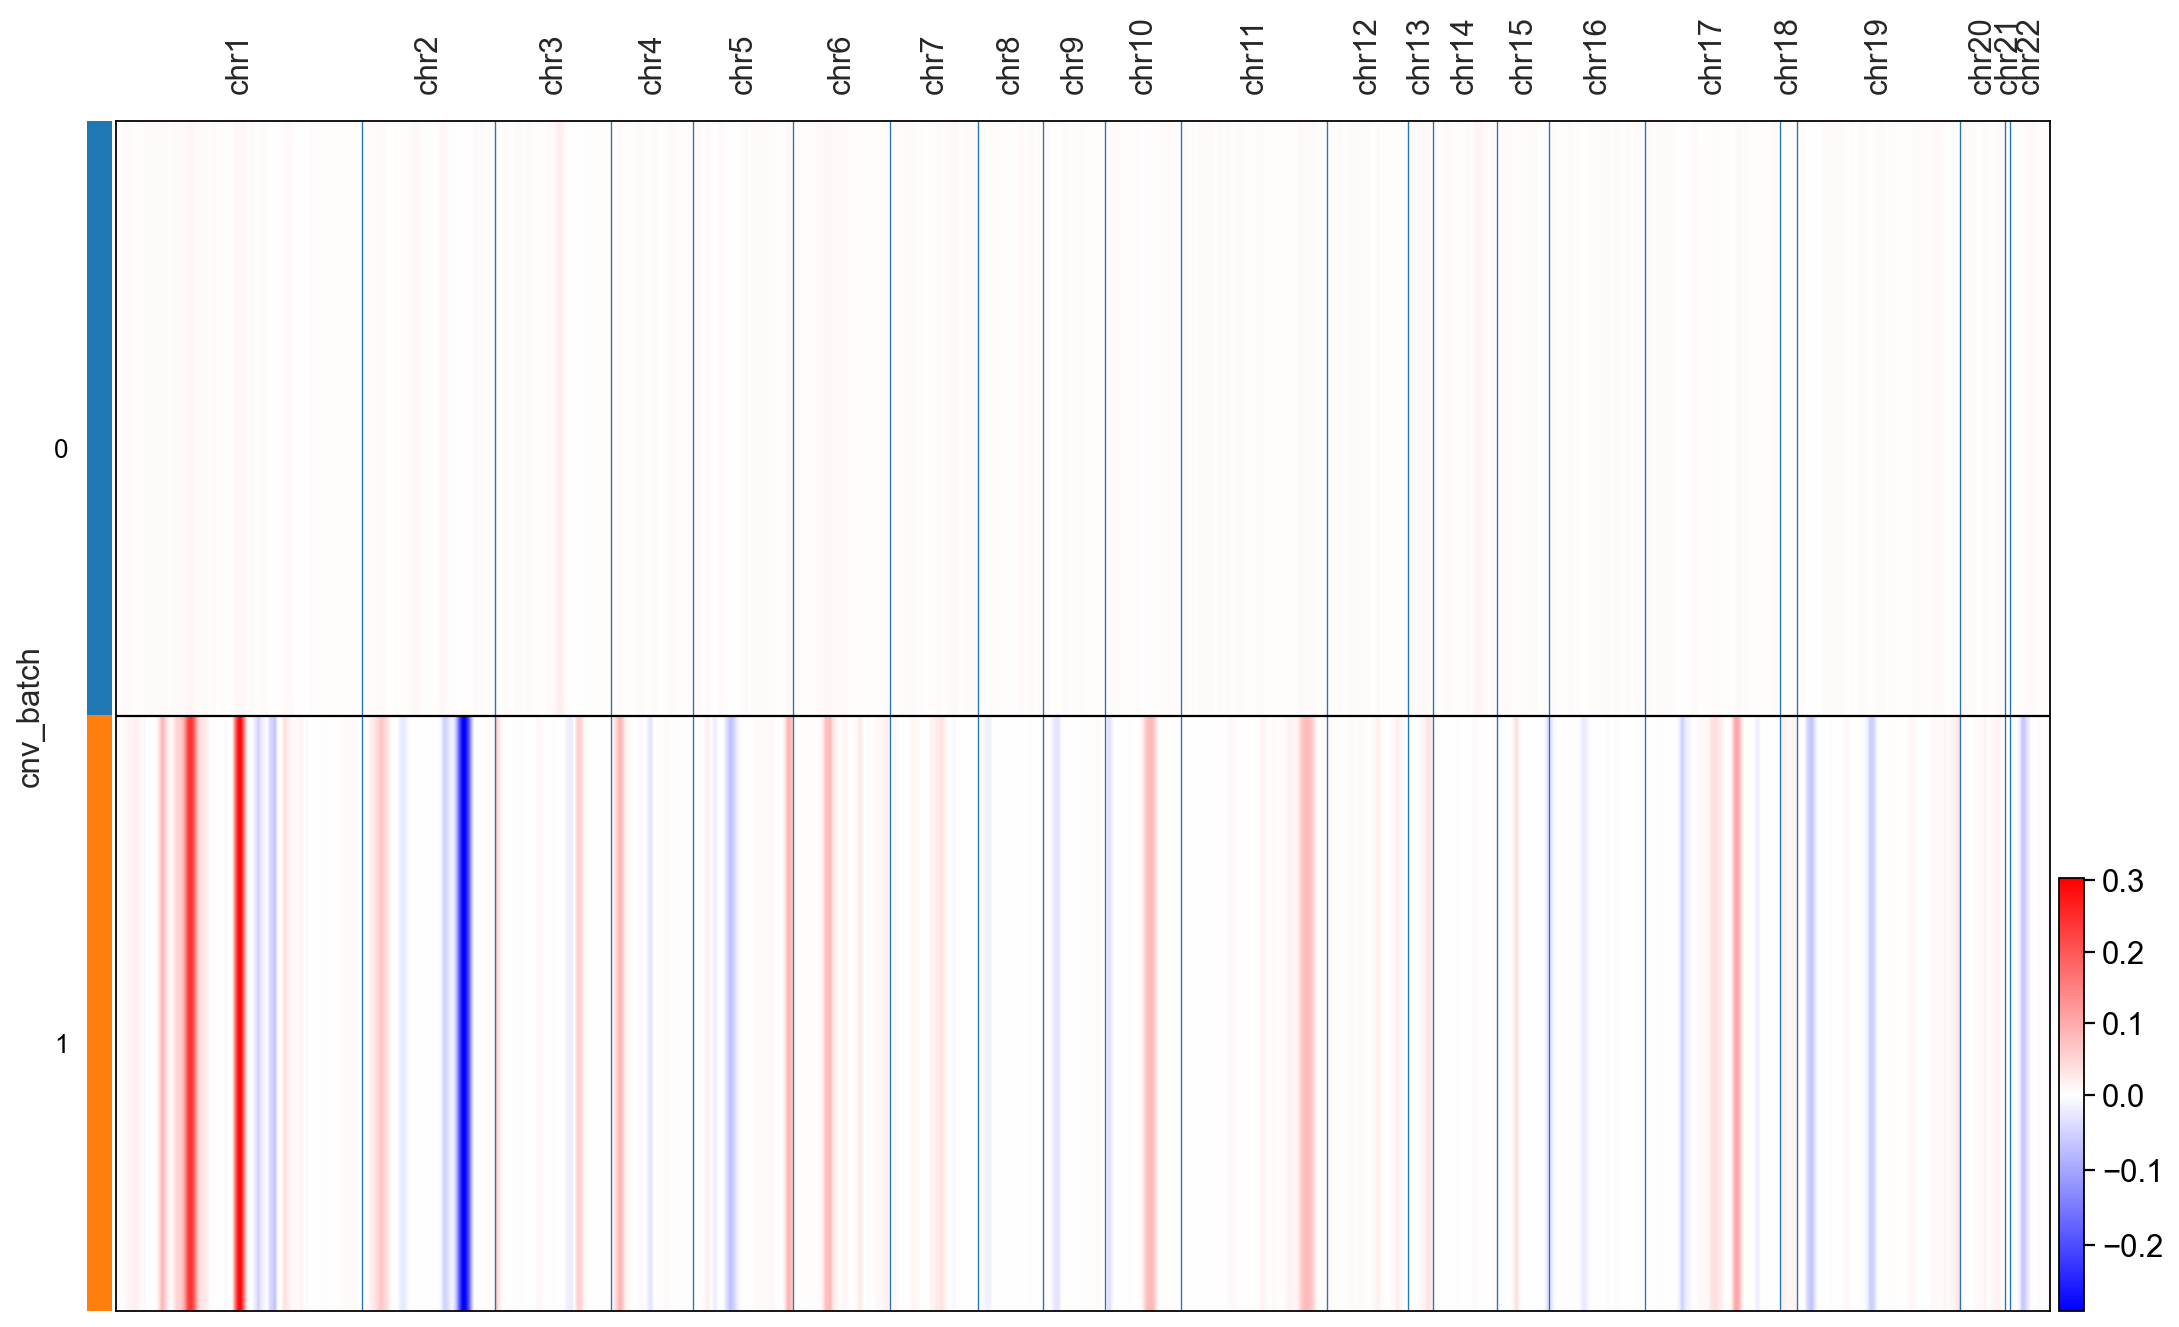

In [41]:
cnv.pl.chromosome_heatmap_summary(merged_adata, figsize=(16,10),groupby="cnv_batch",dendrogram=False,
                          save = "NC_38030622_heatmap_cnv_leiden.pdf")

In [42]:
adata_cnv3 = merged_adata.copy()
cnv.tl.pca(adata_cnv3)
cnv.pp.neighbors(adata_cnv3)
cnv.tl.leiden(adata_cnv3)
cnv.tl.umap(adata_cnv3)
cnv.tl.cnv_score(adata_cnv3)

2026-08-22 13:50:10.726653: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1787377810.749994    9285 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1787377810.757444    9285 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-08-22 13:50:10.786271: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/root/anaconda3/envs/rapids/lib/python3.12/site-packages/infercnvpy/tl/__init__.py:24: FutureWarning: The `igraph` implementa

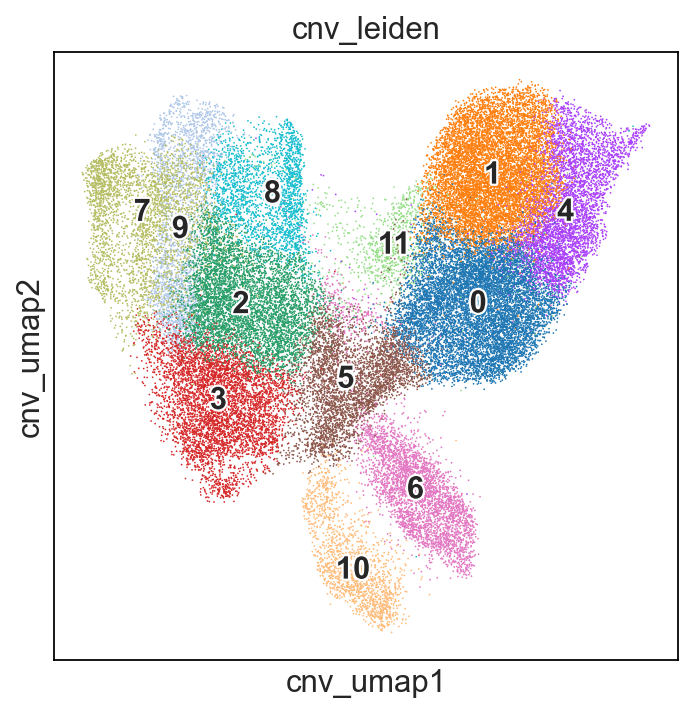

In [43]:
cnv.pl.umap(
    adata_cnv3,
    color="cnv_leiden",
    legend_loc="on data",
    legend_fontoutline=2,
    show=False
)
plt.savefig('NC_38030622_cnv_leiden.pdf', dpi=600, bbox_inches='tight')

In [44]:
print(adata_cnv3.obs['cnv_batch'].value_counts())

cnv_batch
0    33954
1    16250
Name: count, dtype: int64


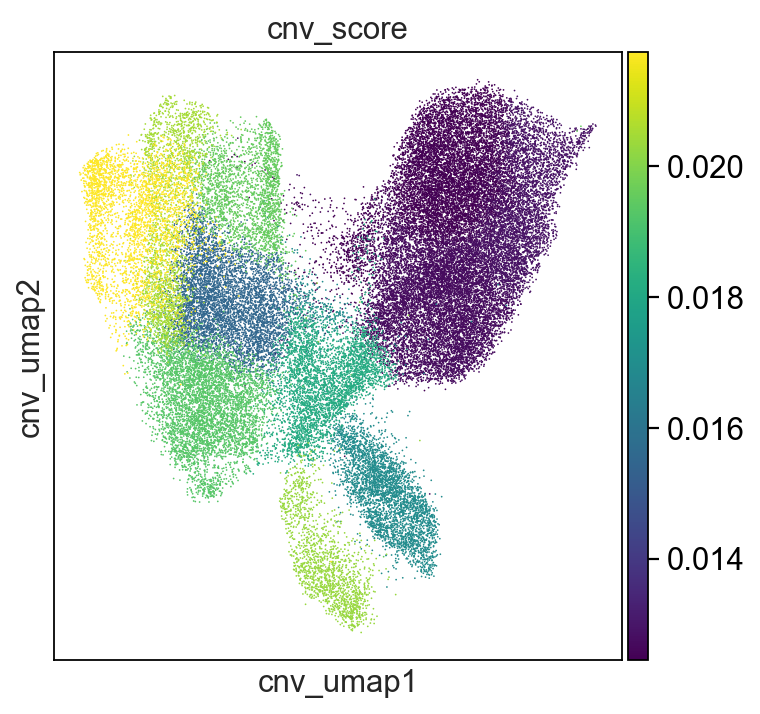

In [45]:
cnv.pl.umap(
    adata_cnv3,
    color="cnv_score",
    cmap= 'viridis',
    legend_loc="on data",
    legend_fontoutline=2,
    show=False
)
plt.savefig('NC_38030622_cnv_score.pdf', dpi=600, bbox_inches='tight')

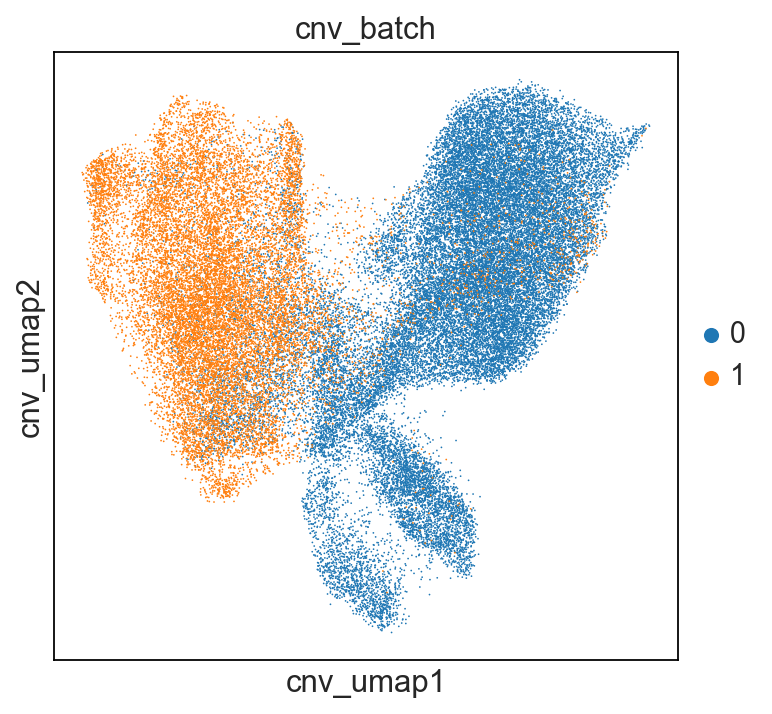

In [46]:
cnv.pl.umap(
    adata_cnv3,
    color="cnv_batch",
    cmap= 'viridis',
    legend_fontoutline=2,
    show=False
)
plt.savefig('NC_38030622_cnv_batch.pdf', dpi=600, bbox_inches='tight')

In [47]:
cluster_means = adata_cnv3.obs.groupby('cnv_leiden')['cnv_score'].mean().sort_values()
cluster_means

/tmp/ipykernel_9285/1901530208.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_means = adata_cnv3.obs.groupby('cnv_leiden')['cnv_score'].mean().sort_values()


cnv_leiden
11    0.012449
1     0.012467
0     0.012735
4     0.012857
2     0.015508
6     0.016934
5     0.018115
3     0.019304
8     0.019562
10    0.020296
9     0.020506
7     0.021747
Name: cnv_score, dtype: float64

In [48]:
diploid_ref = adata_cnv3.obs[adata_cnv3.obs["cnv_batch"] == "0"]
diploid_ref_mean = diploid_ref["cnv_score"].mean()

In [49]:
# #只是供核验数值使用
# diploid_tumor = adata_cnv3.obs[adata_cnv3.obs["cnv_batch"] == "1"]
# diploid_tumor_mean = diploid_tumor["cnv_score"].mean()

In [50]:
diploid_ref_mean

np.float64(0.014470174322688843)

In [51]:
diploid_tumor_mean

np.float64(0.018595672382147245)

In [52]:
diploid_sd = diploid_ref["cnv_score"].std()
diploid_sd

np.float64(0.0027031773778268538)

In [53]:
dipcutoff = diploid_ref_mean+1.5*diploid_sd
dipcutoff

np.float64(0.018524940389429125)

In [54]:
cluster_means

cnv_leiden
11    0.012449
1     0.012467
0     0.012735
4     0.012857
2     0.015508
6     0.016934
5     0.018115
3     0.019304
8     0.019562
10    0.020296
9     0.020506
7     0.021747
Name: cnv_score, dtype: float64

In [55]:
clusters = ["3", "10", "8", "7", "9"]

In [56]:
adsub = adata_cnv3[adata_cnv3.obs['cnv_leiden'].isin(clusters), :].copy()

In [57]:
print(adsub.obs['cnv_batch'].value_counts())

cnv_batch
1    10714
0     3452
Name: count, dtype: int64


In [58]:
adsub = adsub[adsub.obs['cnv_batch'].isin(['1']), :].copy()

In [70]:
adsub = adsub.raw.to_adata()

In [72]:
adsub

AnnData object with n_obs × n_vars = 10714 × 13829
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'response', 'treatment', 'condition', 'group', 'dataset', 'sample', 'lesion', 'doublet_score', 'predicted_doublet', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'total_counts_hb', 'pct_counts_hb', 'total_counts_hsp', 'pct_counts_hsp', 'S_score', 'G2M_score', 'phase', 'cc.difference', 'leiden05', 'leiden02', 'Epi_vs_TME', 'celltype', 'Tumour_ID', 'Patient_ID', 'Response', 'Treatment', 'Week', 'leiden1', 'cnv_batch', 'cnv_leiden', 'cnv_score'
    var: 'features-1', 'chromosome', 'start', 'end', 'n_counts'
    uns: 'log1p', 'cnv', 'cnv_batch_colors', 'cnv_neighbors', 'cnv_leiden', 'cnv_leiden_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_pca_original', 'X_umap', 'X_cnv', 'X_cnv_pca', 'X_cnv_umap'
    obsp: 'cnv_neighbors_distances', 'cnv_neighbors_connectivities'

In [67]:
#删除细胞名合并后末尾的0,1
adsub.obs_names = (
    adsub.obs_names
    .str.replace(r"-(0|1)$", "", regex=True)
)

In [78]:
common_cells = adsub.obs_names.intersection(hepato.obs_names)

print("adsub cells:", adsub.n_obs)
print("hepato cells:", hepato.n_obs)
print("common cells:", len(common_cells))

# 从 hepato（epi的初始input） 中提取
hepato_sub = hepato[common_cells].copy() 

adsub cells: 10714
hepato cells: 28332
common cells: 10714


In [82]:
#检查矩阵数值
from scipy import sparse

X = hepato_sub.X

if sparse.issparse(X):
    vals = X.data
else:
    vals = np.asarray(X).ravel()

has_decimal = np.any(vals != np.round(vals))

print("dtype:", X.dtype)
print("has decimal:", has_decimal)
print("min:", vals.min())
print("max:", vals.max())

dtype: float64
has decimal: False
min: 1.0
max: 4144.0


# 2. Scanpy

In [83]:
epi = hepato_sub.copy()

In [ ]:
genes_in_adata = epi.var_names
filtered_genes = [gene for gene in genes_in_adata if gene in protein_coding_genes]
epi = epi[:, filtered_genes].copy()

In [87]:
epi.raw = epi.copy()

In [89]:
epi.layers["counts"] = epi.X.copy() # preserve counts
sc.pp.normalize_total(epi, target_sum=1e4) # Total-count normalize to 10000
sc.pp.log1p(epi) # Logarithmize the data
epi.layers["log1p"] = epi.X.copy()

In [90]:
def process_data_hvg(adata, n_hvg, verbose=True):
    import scanpy as sc
    import harmonypy as hm
    
    adata = adata.copy()

    if verbose:
        print(f"\n▶ HVG = {n_hvg}")

    # HVG（基于 counts）
    sc.pp.highly_variable_genes(
        adata,
        flavor="seurat_v3",
        n_top_genes=n_hvg,
        layer="counts"
    )
    
    adata = adata[:, adata.var.highly_variable].copy()

    # regress out（基于 log1p）
    sc.pp.regress_out(
        adata, 
        ['total_counts', 'pct_counts_mt', 'cc.difference', 'pct_counts_rb'],
        n_jobs=30
    )

    # scale
    sc.pp.scale(adata, max_value=10)

    # PCA
    sc.tl.pca(adata, n_comps=30, svd_solver='arpack')

    # Harmony
    X_pca = adata.obsm["X_pca"]
    meta = adata.obs[["sample"]].astype(str)

    ho = hm.run_harmony(X_pca, meta, vars_use=["sample"])
    Z = ho.Z_corr

    if Z.shape[0] != adata.n_obs:
        Z = Z.T

    adata.obsm["X_pca_original"] = X_pca.copy()
    adata.obsm["X_pca_harmony"] = Z.copy()

    
    return adata

In [91]:
epi = process_data_hvg(epi, 3000, verbose=True)


▶ HVG = 3000


2026-08-22 14:23:38,933 - harmonypy - INFO - Running Harmony (PyTorch on cuda)
2026-08-22 14:23:38,935 - harmonypy - INFO -   Parameters:
2026-08-22 14:23:38,935 - harmonypy - INFO -     max_iter_harmony: 10
2026-08-22 14:23:38,936 - harmonypy - INFO -     max_iter_kmeans: 20
2026-08-22 14:23:38,936 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-08-22 14:23:38,937 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-08-22 14:23:38,938 - harmonypy - INFO -     nclust: 100
2026-08-22 14:23:38,939 - harmonypy - INFO -     block_size: 0.05
2026-08-22 14:23:38,940 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1.]
2026-08-22 14:23:38,941 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2.]
2026-08-22 14:23:38,941 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-08-22 14:23:38,942 - harmonypy - INFO -     verbose: True
2026-08-22 14:23:38,943 - harmonyp

In [92]:
sc.pp.neighbors(
    epi,
    use_rep="X_pca_harmony",
    n_neighbors=10
)

sc.tl.umap(epi)

In [93]:
sc.tl.leiden(epi, resolution=1, key_added="leiden1", flavor="igraph", n_iterations=2, directed=False)
sc.tl.leiden(epi, resolution=0.5, key_added="leiden05", flavor="igraph", n_iterations=2, directed=False)

In [175]:
sc.tl.leiden(epi, resolution=0.2, key_added="leiden02", flavor="igraph", n_iterations=2, directed=False)

<Axes: title={'center': 'Resolution = 0.5'}, xlabel='UMAP1', ylabel='UMAP2'>

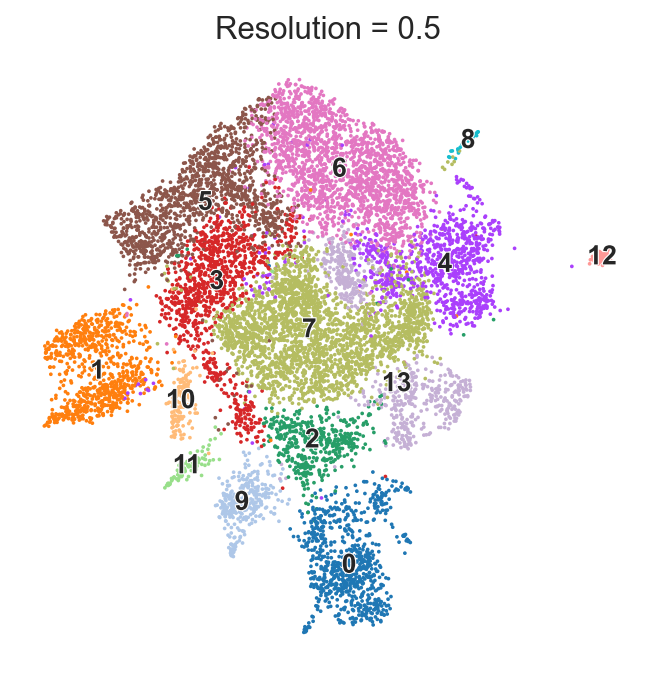

In [94]:
sc.pl.umap(epi, color=['leiden05'], legend_loc='on data',title='Resolution = 0.5', frameon = False, legend_fontsize=12, legend_fontoutline=1,show = False)
#plt.savefig('T+A_HCC_Epi_UMAP_res1.pdf', dpi=600, bbox_inches='tight')

<Axes: title={'center': 'Resolution = 0.2'}, xlabel='UMAP1', ylabel='UMAP2'>

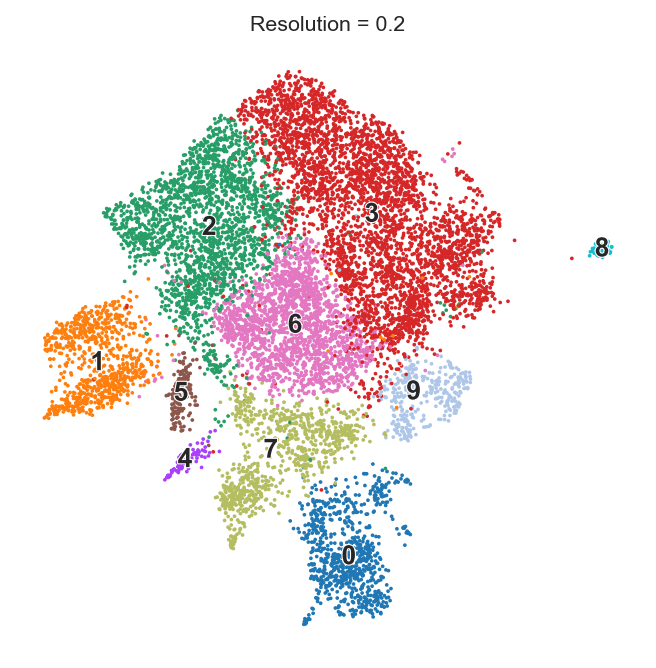

In [177]:
sc.pl.umap(epi, color=['leiden02'], legend_loc='on data',title='Resolution = 0.2', frameon = False, legend_fontsize=12, legend_fontoutline=1,show = False)
#plt.savefig('T+A_HCC_Epi_UMAP_res1.pdf', dpi=600, bbox_inches='tight')

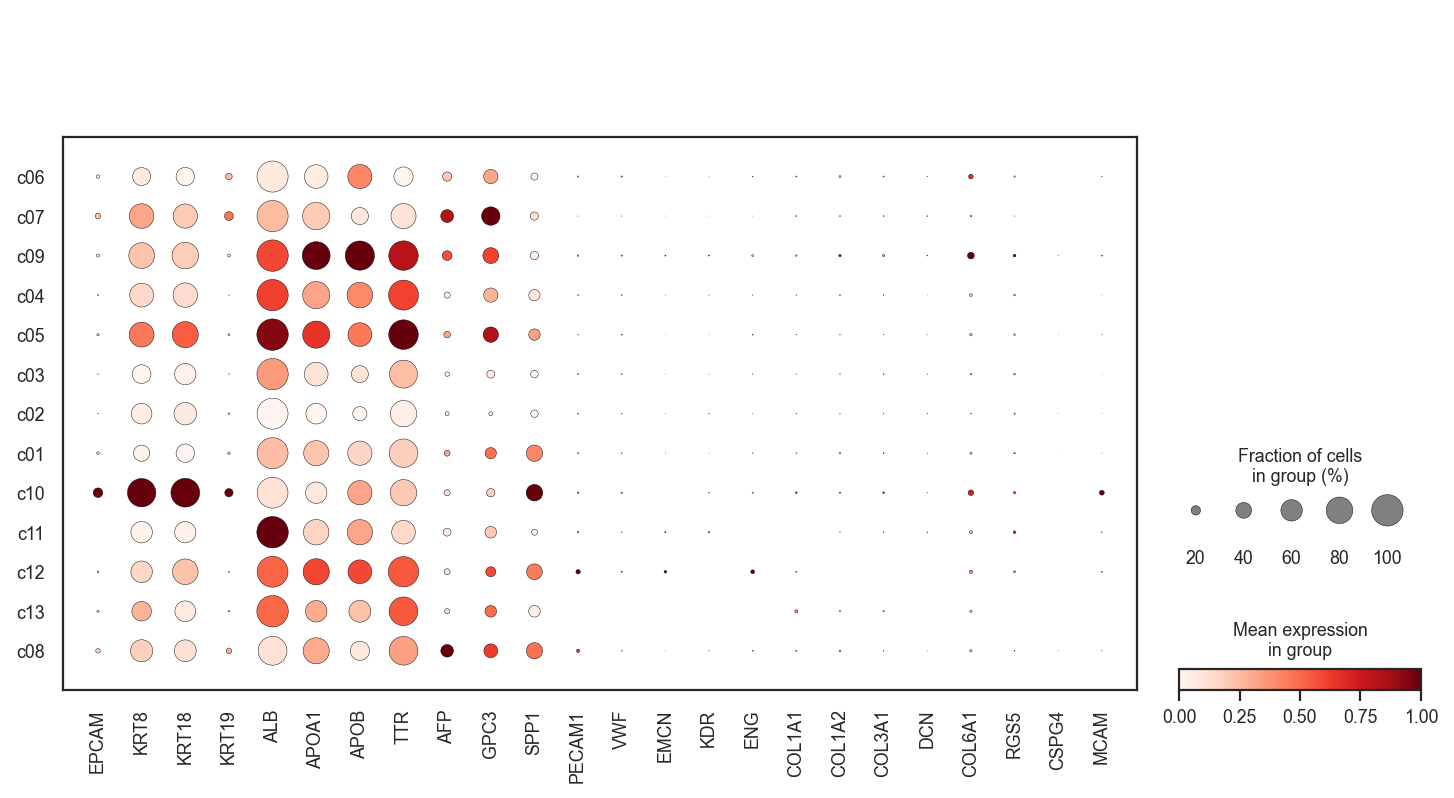

In [179]:
genes_check = [
    # epithelial / hepatocyte
    "EPCAM", "KRT8", "KRT18", "KRT19",
    "ALB", "APOA1", "APOB", "TTR",

    # malignant/HCC
    "AFP", "GPC3", "SPP1",

    # endothelial
    "PECAM1", "VWF", "EMCN", "KDR", "ENG",

    # mesenchymal/pericyte
    "COL1A1", "COL1A2", "COL3A1",
    "DCN", "COL6A1", "RGS5", "CSPG4", "MCAM"
]

sc.pl.dotplot(
    epi,
    genes_check,
    groupby="label",
    standard_scale="var"
)

In [183]:
adsub

AnnData object with n_obs × n_vars = 10714 × 13829
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'response', 'treatment', 'condition', 'group', 'dataset', 'sample', 'lesion', 'doublet_score', 'predicted_doublet', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'total_counts_hb', 'pct_counts_hb', 'total_counts_hsp', 'pct_counts_hsp', 'S_score', 'G2M_score', 'phase', 'cc.difference', 'leiden05', 'leiden02', 'Epi_vs_TME', 'celltype', 'Tumour_ID', 'Patient_ID', 'Response', 'Treatment', 'Week', 'leiden1', 'cnv_batch', 'cnv_leiden', 'cnv_score'
    var: 'features-1', 'chromosome', 'start', 'end', 'n_counts'
    uns: 'log1p', 'cnv', 'cnv_batch_colors', 'cnv_neighbors', 'cnv_leiden', 'cnv_leiden_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_pca_original', 'X_umap', 'X_cnv', 'X_cnv_pca', 'X_cnv_umap'
    obsp: 'cnv_neighbors_distances', 'cnv_neighbors_connectivities'

In [184]:
epi.obs["cnv_score"] = epi.obs_names.map(
    adsub.obs["cnv_score"]
)

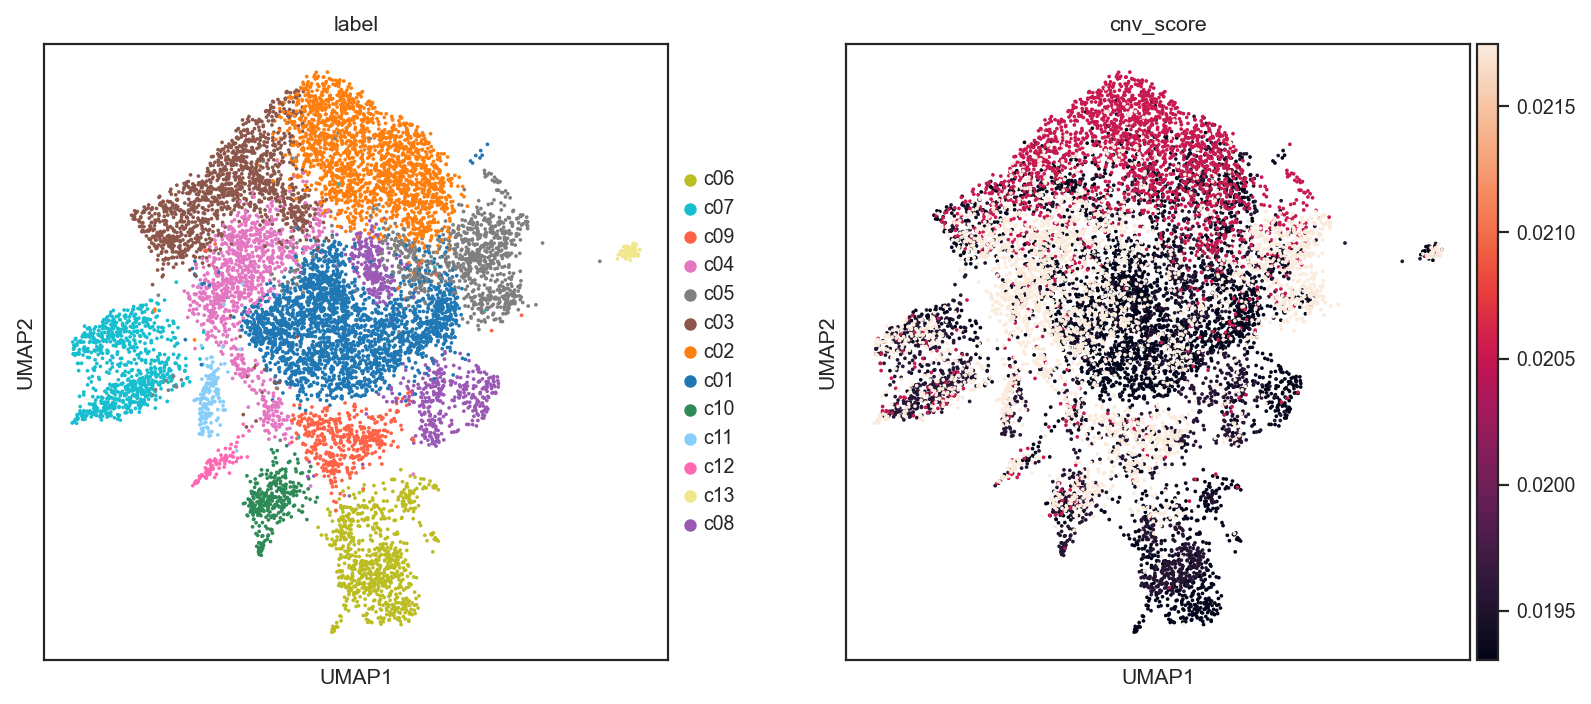

In [185]:
sc.pl.umap(
    epi,
    color=["label", "cnv_score"],
    ncols=2
)

In [178]:
groupby='leiden02'
cosg.cosg(
   epi,
   key_added='cosg_02',
   use_raw=False, layer='log1p', 
   mu=100,
   expressed_pct=0.1,
   remove_lowly_expressed=True,
   n_genes_user=epi.n_vars,
   groupby=groupby,
   return_by_group=True,
    verbosity=1 )
marker_gene=pd.DataFrame(epi.uns['cosg_02']['names'])
marker_gene.head(50)

Finished identifying marker genes by COSG, and the results are in adata.uns['cosg_02'].


,0,1,2,3,4,5,6,7,8,9
0,TRIM73,UBE2C,CYP1A2,AKR1C4,PRF1,MATN3,UGT2B17,KRT7,CYP17A1,DLK1
1,SLC25A27,RRM2,SPDEF,HPD,CTSW,ANKFN1,UGT1A9,MAMDC4,TMED3,NTS
2,SLC22A25,SPC25,CYP8B1,ADH1C,TRAT1,MYH7B,CRP,ARRDC2,ALPL,CDH17
3,ANKRD36,CDK1,CYP3A4,ADH1A,CST7,CCDC3,A2M,OLFM2,PTGDS,PRSS2
4,CCDC144A,CDC20,C3orf85,ARG1,GZMH,PAQR8,SPP1,CITED4,SERPINE1,TRIM54
5,RNF207,CDCA3,APOC4,GSTM1,PTPN7,KLK4,LBP,SOX9,CPNE1,DUOXA2
6,SCN8A,CCNB1,BCHE,FBP1,GZMB,ATP1A2,UGT1A4,GPR88,DERL3,CD177
7,RNPC3,CCNA2,MT1X,ADH1B,CYTIP,TMEM100,HSPA5,GLDC,ANLN,UGT1A8
8,NKTR,MAD2L1,CYP2C9,ASS1,CX3CR1,ANGPTL2,PRG4,HSD17B13,ASPM,AGR2
9,NBPF11,PTTG1,RPS4Y1,DCXR,KLRB1,TSPAN5,UGT2B4,FLNA,CENPE,TFF3


In [236]:
gene1 =["SCN1A","TRPM3","ROBO2","AFP","HAVCR1","PCSK1N","CADPS","CALCA","NAT8L","B3GALT1","PEG3",
       "GLP1R","ADGRD1","CADM2","USP27X","AIFM2",
       "TYSND1","KIF26B","SYN3","VEGFD","ADAM23","B9D1","FAM110B","GLUD1","FRRS1L","IZUMO1","ECEL1",
       "SLC30A2","BSN","BCAS1","CSPP1","IGDCC4","NKAIN1","RHBDL3","SCARA3",
       "OCA2","GLUD2","CAGE1","DLK1","DGKK","ADARB2",
       "REG3A","AZIN1","ZNF233","NSUN7","RELN","SNTG1","RASD1","ABCB5","CTNNA2","PLPPR1","HSD17B3"]

gene2 = [
    "MBNL3", "REG3A", "GLUD1", "AFP", "PLPPR1",
    "AIFM2", "CACFD1", "C1QTNF3", "B9D1", "RELN",
    "NR6A1", "FAM110B", "PCSK1N", "ADGRD1", "CTNNA2",
    "GLUD2", "PEG3", "SNTG1", "OCA2", "MAMSTR",
    "SCARA3", "BSN", "SYN3", "HAVCR1", "ROBO2",
    "DLK1", "TRPM3", "CALCA", "NSUN7"
]

gene3 = [
    "REG3A",
    "AIFM2",
    "CTNNA2",
    "GLUD1",
    "CACFD1"
]

In [ ]:
gene4 = [
    "REG3A",
    "AIFM2",
    "CTNNA2",
    "GLUD1",
    "CACFD1"
]

In [96]:

sc.tl.score_genes(
    epi,
    gene_list=gene1,
    score_name="Bulk_resistant_score",
    use_raw=True
)
sc.tl.score_genes(
    epi,
    gene_list=gene2,
    score_name="Bulk_resistant_score_filt",
    use_raw=True
)

In [237]:
sc.tl.score_genes(
    epi,
    gene_list=gene3,
    score_name="Bulk_resistant_score_core",
    use_raw=True
)

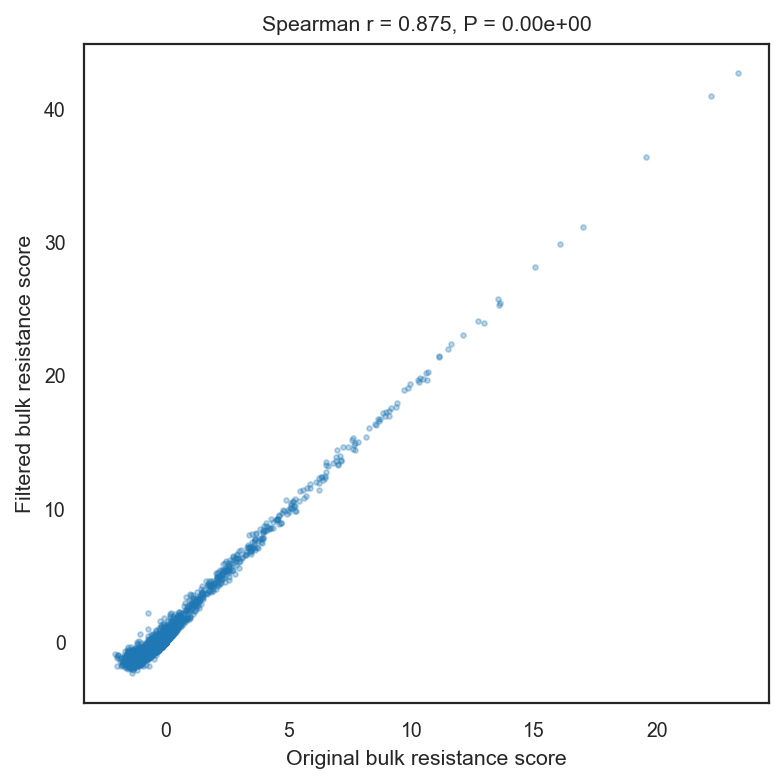

In [279]:
from scipy.stats import spearmanr

x = epi.obs["Bulk_resistant_score"]
y = epi.obs["Bulk_resistant_score_filt"]

rho, pval = spearmanr(x, y)

plt.figure(figsize=(5, 5))
plt.scatter(x, y, s=5, alpha=0.3)

plt.xlabel("Original bulk resistance score")
plt.ylabel("Filtered bulk resistance score")
plt.title(f"Spearman r = {rho:.3f}, P = {pval:.2e}")

plt.tight_layout()
#plt.savefig('NC_38030622_Unfilter_vs_filter_bulk_res_score_spearman.pdf', dpi=600, bbox_inches='tight')
plt.show()

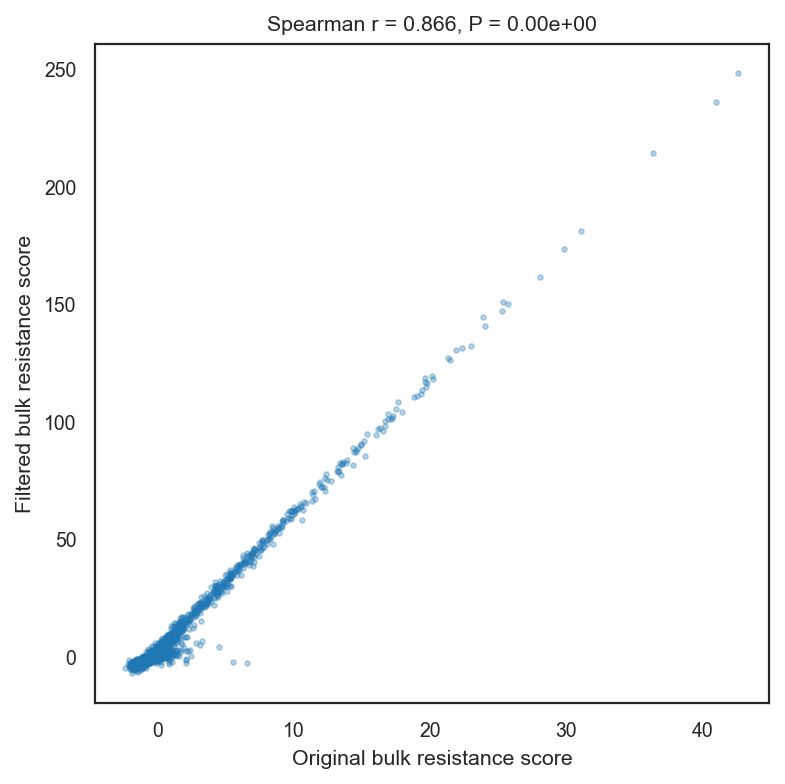

In [238]:
from scipy.stats import spearmanr

x = epi.obs["Bulk_resistant_score_filt"]
y = epi.obs["Bulk_resistant_score_core"]

rho, pval = spearmanr(x, y)

plt.figure(figsize=(5, 5))
plt.scatter(x, y, s=5, alpha=0.3)

plt.xlabel("Original bulk resistance score")
plt.ylabel("Filtered bulk resistance score")
plt.title(f"Spearman r = {rho:.3f}, P = {pval:.2e}")

plt.tight_layout()
#plt.savefig('NC_38030622_Unfilter_vs_filter_bulk_res_score_spearman.pdf', dpi=600, bbox_inches='tight')
plt.show()

In [100]:
cluster_counts = epi.obs["leiden05"].value_counts()

# 这个顺序就是你想要的排序（从细胞数多到少）
ordered_clusters = cluster_counts.index.tolist()

# 2. 按这个顺序创建新的连续编号：c01, c02, ...
new_names = {
    old: f"c{str(i + 1).zfill(2)}"   # c01, c02, ...
    for i, old in enumerate(ordered_clusters)
}

# 3. 替换到新的字段 label 中
epi.obs["label"] = epi.obs["leiden05"].map(new_names)

# 4. 看看映射结果
epi.obs[["label", "leiden05"]].head()

,label,leiden05
AAACGGGGTTGTCTTT-1_tumour_1,c06,0
AAAGTAGGTACTCGCG-1_tumour_1,c07,1
AACACGTTCTTAGCCC-1_tumour_1,c04,3
AACGTTGTCGCCTGTT-1_tumour_1,c03,5
AACTCCCGTAGAGTGC-1_tumour_1,c04,3


In [117]:
colors = [
    "#1f77b4", "#ff7f0e",  "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
    "#9b59b6", "#ff6347", "#2e8b57", "#87cefa", "#ff69b4", "#f0e68c", "#dda0dd", "#ff4500", "#32cd32", "#ff1493",
    "#8b0000", "#b22222", "#a52a2a", "#800080", "#ffd700", "#ff8c00", "#f08080", "#c71585", "#d3d3d3", "#ff0000",
    "#c0c0c0", "#8b4513", "#3cb371", "#bdb76b", "#00ced1", "#a52a2a", "#f4a460", "#2f4f4f", "#228b22", "#ff1493",
    "#ff6347", "#da70d6", "#cd5c5c", "#9acd32", "#8a2be2", "#a52a2a", "#9b30ff", "#ff00ff", "#adff2f", "#ff6347",
    "#e0ffff", "#f0fff0", "#ffdab9", "#d3ffce", "#98fb98", "#ffcccb", "#f5f5dc", "#c8a2c8", "#dda0dd", "#d2691e",
    "#8b0000", "#e9967a", "#cd5c5c", "#f08080", "#ff69b4", "#a8a8a8", "#7fff00", "#dcdcdc", "#ffb6c1", "#98fb98",
    "#ff4500", "#ff6347", "#ff8c00", "#fa8072", "#ff4500", "#ff6347", "#f5fffa", "#a52a2a", "#a52a2a", "#d2691e",
    "#ff4500", "#a52a2a", "#b22222", "#ff6347", "#2e8b57", "#8b4513", "#a52a2a", "#c71585", "#ff1493", "#c71585",
    "#ff5500", "#97b7d9", "#00429d", "#bc3e3e", "#47a5c1", "#d4c100", "#B6BC55", "#cb6d0d", "#7d7250", "#6d3567",
    "#2a96c1", "#f5ae3c", "#c4f3a4", "#4f007d", "#ff8b1a", "#588d88", "#bdd95b", "#5374a1", "#F1E39C", "#9e5c25",
    "#4d4d9e", "#7b70d2", "#f4b0c3", "#23ad54", "#f1611b", "#faecf2", "#5a57a1", "#d8d08f", "#CBE635", "#825130",
    "#afffef", "#6972b4", "#0d477d", "#ddcc44", "#a53993", "#b1a5f7", "#fbcfc4", "#f2d9aa", "#769ca2", "#a6d4f2"]

color_dict = {
    cat: colors[i]
    for i, cat in enumerate(
        [f"c{i:02d}" for i in range(1, 15)] + ["Mixed"]
    )
}

In [118]:
color_dict

{'c01': '#1f77b4',
 'c02': '#ff7f0e',
 'c03': '#8c564b',
 'c04': '#e377c2',
 'c05': '#7f7f7f',
 'c06': '#bcbd22',
 'c07': '#17becf',
 'c08': '#9b59b6',
 'c09': '#ff6347',
 'c10': '#2e8b57',
 'c11': '#87cefa',
 'c12': '#ff69b4',
 'c13': '#f0e68c',
 'c14': '#dda0dd',
 'Mixed': '#ff4500'}

In [141]:
# epi_markers = {
#     "Pan_epithelial": ["EPCAM", "KRT8"],
#     "Hepatocytes": ["ALB", "ASGR1", "APOB", "CPS1", "ASS1", "PCK1", "CYP3A4"],
#     "Cholangiocytes": ["CFTR", "KRT19", "KRT7", "SOX9", "SPP1", "MUC1", "MUC6", "LCN2", "CD24"],
#     "Progenitor cells": ["DLK1", "GPC3", "ONECUT1", "HNF4A", "NCAM1", "SPINK1", "SOX4"]
# }

In [112]:
len(epi.obs['label'].unique())

14

In [154]:
order = [f"c{i:02d}" for i in range(1,14)]

In [109]:
epi = epi.raw.to_adata()

/tmp/ipykernel_9285/2008507444.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(


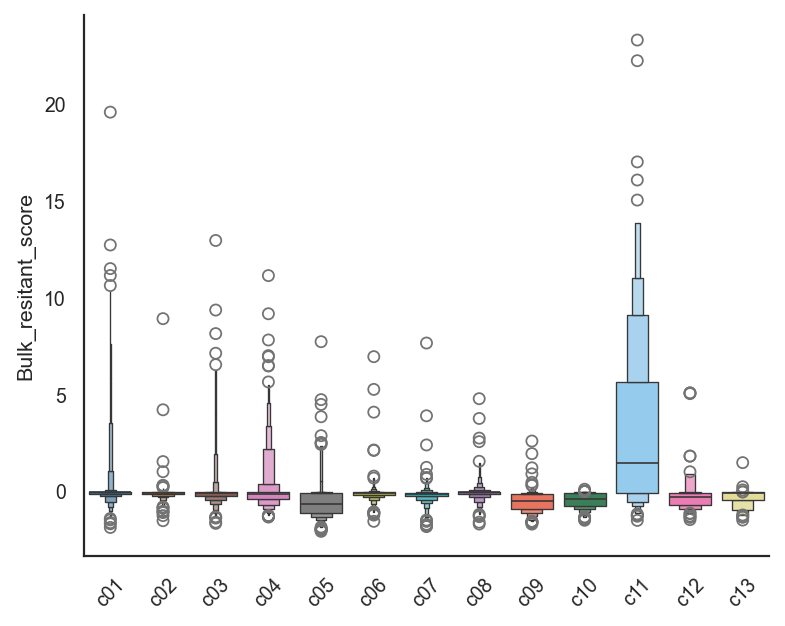

In [155]:
fig, ax = plt.subplots(figsize=(5,4))

sns.boxenplot(
    data=epi.obs,
    x="label",
    y="Bulk_resistant_score",
    order=order,
    palette=color_dict
)

plt.xticks(rotation=45)
plt.xlabel("")
plt.ylabel("Bulk_resitant_score")

sns.despine()

plt.tight_layout()
plt.savefig("NC_38030622_boxenplot_Bulk_resitant_score.pdf", dpi=600, bbox_inches="tight")
plt.show()

/tmp/ipykernel_9285/1751715367.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(


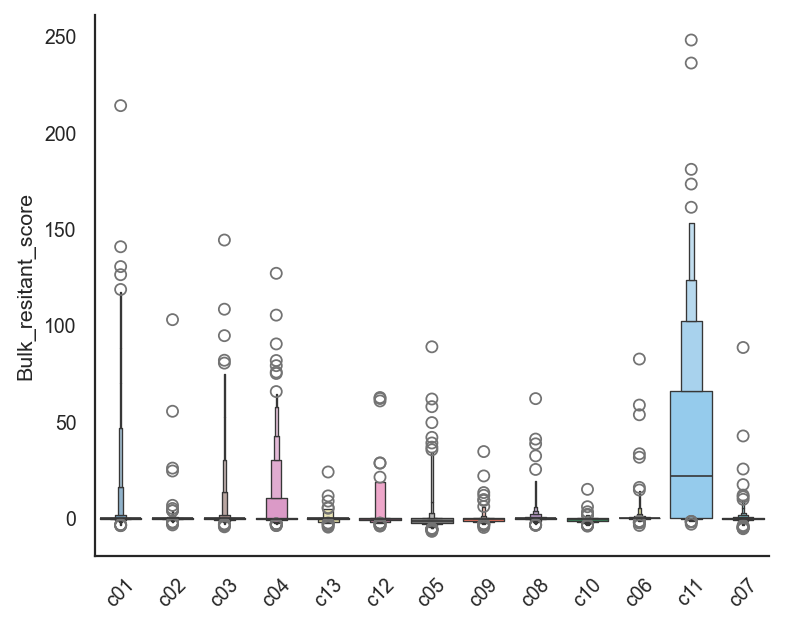

In [240]:
fig, ax = plt.subplots(figsize=(5,4))

sns.boxenplot(
    data=epi.obs,
    x="label",
    y="Bulk_resistant_score_core",
    order=order,
    palette=color_dict
)

plt.xticks(rotation=45)
plt.xlabel("")
plt.ylabel("Bulk_resitant_score")

sns.despine()

plt.tight_layout()
#plt.savefig("NC_38030622_boxenplot_Bulk_resitant_score.pdf", dpi=600, bbox_inches="tight")
plt.show()

In [148]:
print(epi.obs['label'].value_counts())

label
c01    2437
c02    1860
c03    1266
c04     976
c05     922
c06     789
c07     787
c08     590
c09     427
c10     327
c11     155
c12      83
c13      68
c14      27
Name: count, dtype: int64


In [156]:
import cosg
groupby='label'
cosg.cosg(
   epi,
   key_added='cosg_05',
   use_raw=False, layer='log1p', 
   mu=100,
   expressed_pct=0.1,
   remove_lowly_expressed=True,
   n_genes_user=epi.n_vars,
   groupby=groupby,
   return_by_group=True,
    verbosity=1 )
marker_gene=pd.DataFrame(epi.uns['cosg_05']['names'])
marker_gene.head(50)

Finished identifying marker genes by COSG, and the results are in adata.uns['cosg_05'].


,c06,c07,c09,c04,c05,c03,c02,c01,c10,c11,c12,c13,c08
0,TRIM73,UBE2C,MAMDC4,CYP1A2,SAA4,RPS4Y1,GSTM1,UGT2B17,SFRP5,MATN3,CTSW,CYP17A1,NTS
1,SLC25A27,RRM2,GPR88,CYP8B1,APOM,HPD,PAGE4,SPP1,CLDN10,ANKFN1,PRF1,TMED3,GAGE2A
2,ANKRD36,CDK1,HSD17B13,CLDN2,SLC10A1,GNMT,ADH1C,CRP,KRT7,MYH7B,TRAT1,PTGDS,TFF3
3,SLC22A25,SPC25,IGSF9,SPDEF,CFHR2,ADH1A,HPD,LBP,BICC1,CCDC3,PTPN7,ALPL,AGR2
4,CCDC144A,CDC20,OLFM2,FAM169A,MASP2,DCXR,AKR1C4,UGT1A9,SLC12A2,PAQR8,GZMH,SERPINE1,UGT1A5
5,RNF207,CDCA3,MROH2A,SSTR1,CDA,BCHE,GSTA2,A2M,PMEPA1,KLK4,CST7,CPNE1,CA9
6,RNPC3,CCNB1,GLDC,SLCO1B3,FXYD1,ADH4,FBP1,HSPA5,IL18,TMEM100,GZMB,DERL3,TFF2
7,NBPF11,PTTG1,RALGPS1,CYP3A4,SHD,GSTM1,ADH1A,PDIA3,VEPH1,ATP1A2,CD3E,ANLN,SLC1A7
8,NKTR,CCNA2,CYP2A7,C3orf85,SERPINC1,ADH1B,ADH1B,UGT2B4,RIC3,CDCA7,CYTIP,CENPE,PNCK
9,GOLGA8B,MAD2L1,SYT7,AQP9,APOC4,CYP2E1,DCXR,CES1,CREB5,ANGPTL2,KLRB1,KIF20A,CCL20


In [149]:
epi = epi[~epi.obs['label'].isin(['c14']), :].copy() #剔除细胞<50的亚群

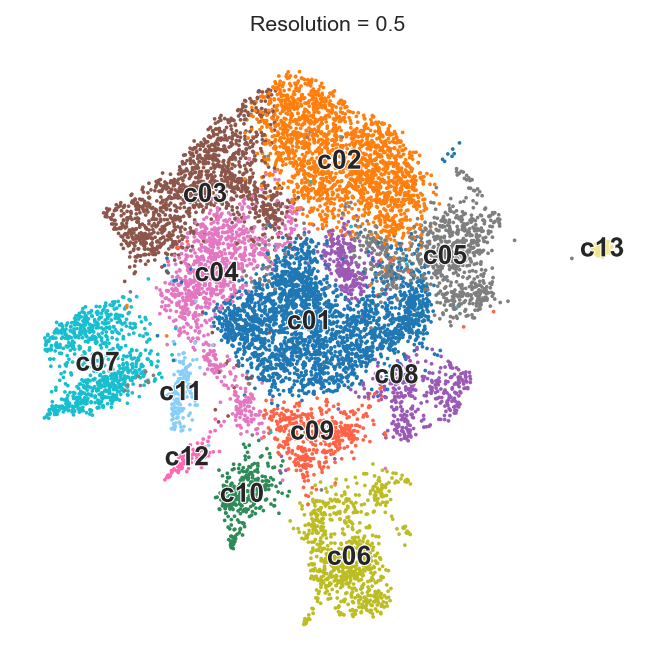

In [150]:
sc.pl.umap(epi, color=['label'], legend_loc='on data',palette=color_dict,
           title='Resolution = 0.5', frameon = False, legend_fontsize=12, legend_fontoutline=1,show = False)
plt.savefig('NC_38030622_Epi_UMAP_res0.5.pdf', dpi=600, bbox_inches='tight')

In [151]:
epi.write('NC_38030622_epi_infercnv.h5ad')

/tmp/ipykernel_9285/1464076962.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sc.pl.umap(epi, color=['Bulk_resistant_score'], cmap=plt.cm.get_cmap('magma').reversed(),vmin=0.5,


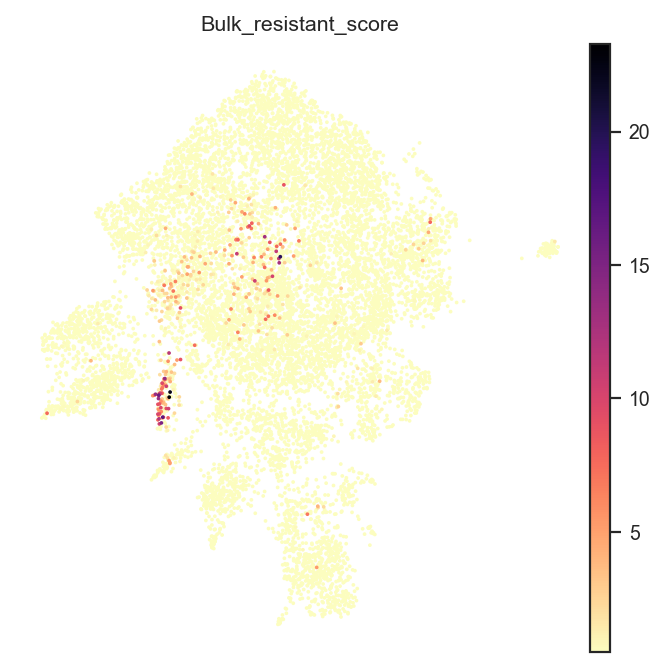

In [152]:
sc.pl.umap(epi, color=['Bulk_resistant_score'], cmap=plt.cm.get_cmap('magma').reversed(),vmin=0.5,  
           frameon = False, legend_fontsize=12, legend_fontoutline=1,show = False)
plt.savefig('NC_38030622_UMAP_Bulk_resistant_score.pdf', dpi=600, bbox_inches='tight')

c11 cell number: 155
Patient_ID
pat3     96
pat12    11
pat16    10
pat36     7
pat13     6
pat14     5
pat37     5
pat8      5
pat31     3
pat6      2
pat34     2
pat21     1
pat17     1
pat22     1
pat15     0
pat4      0
pat19     0
pat18     0
pat25     0
pat24     0
pat23     0
pat20     0
pat33     0
pat32     0
pat26     0
pat35     0
Name: count, dtype: int64
Patient_ID
pat3     61.935484
pat12     7.096774
pat16     6.451613
pat36     4.516129
pat13     3.870968
pat14     3.225806
pat37     3.225806
pat8      3.225806
pat31     1.935484
pat6      1.290323
pat34     1.290323
pat21     0.645161
pat17     0.645161
pat22     0.645161
pat15     0.000000
pat4      0.000000
pat19     0.000000
pat18     0.000000
pat25     0.000000
pat24     0.000000
pat23     0.000000
pat20     0.000000
pat33     0.000000
pat32     0.000000
pat26     0.000000
pat35     0.000000
Name: count, dtype: float64


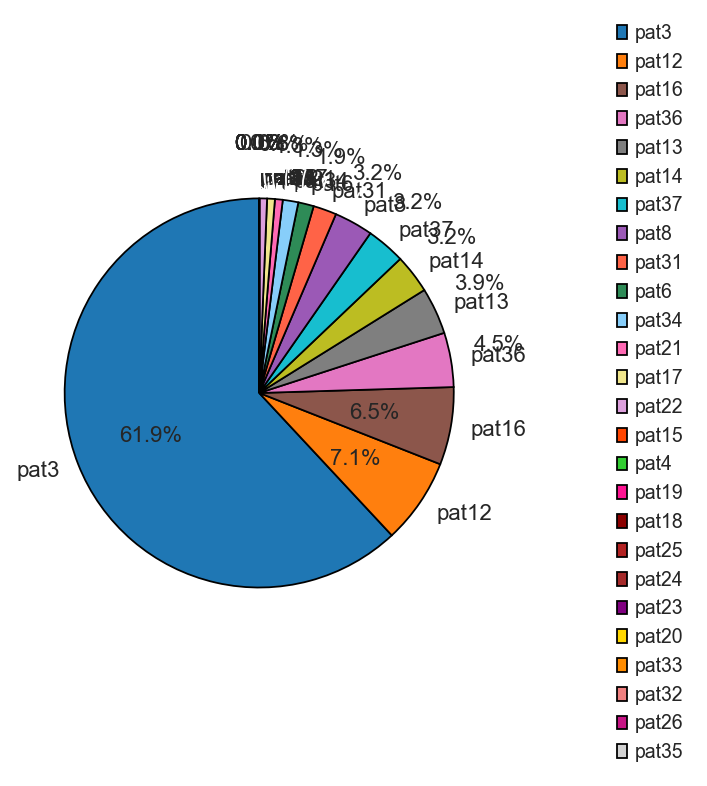

In [147]:
# =========================
# 1. 提取 c11 细胞
# =========================
df = epi.obs.copy()

c11_df = df[df["label"] == "c11"].copy()

print("c11 cell number:", c11_df.shape[0])

# =========================
# 2. 统计每个样本来源的细胞数
# =========================
sample_counts = c11_df["Patient_ID"].value_counts()

percentages = (
    sample_counts / sample_counts.sum() * 100
)

print(sample_counts)
#print(percentages)

# =========================
# 3. 绘制饼图
# =========================
fig, ax = plt.subplots(figsize=(5, 4))

wedges, texts, autotexts = ax.pie(
    sample_counts,
    labels=sample_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "black"}
)

# 标签字体
for text in texts:
    text.set_fontsize(10)

for autotext in autotexts:
    autotext.set_fontsize(10)

# =========================
# 4. 小于5%的标签移到外部
# =========================
for i, (p, pct) in enumerate(zip(wedges, percentages)):

    if pct < 5:

        ang = (p.theta2 - p.theta1) / 2. + p.theta1

        x = 1.25 * p.r * np.cos(np.radians(ang))
        y = 1.25 * p.r * np.sin(np.radians(ang))

        autotexts[i].set_visible(False)

        ax.annotate(
            f"{pct:.1f}%",
            xy=(
                p.r * np.cos(np.radians(ang)),
                p.r * np.sin(np.radians(ang))
            ),
            xytext=(x, y),
            arrowprops=dict(
                arrowstyle="->",
                connectionstyle="arc3,rad=.3"
            ),
            ha="center",
            fontsize=10
        )

# =========================
# 5. 图例
# =========================
plt.legend(
    sample_counts.index,
    title="",
    loc="center left",
    bbox_to_anchor=(1.2, 0, 0.5, 1),
    frameon=False
)

plt.title("")

plt.savefig(
    "c11_sample_origin_pie.pdf",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# 3. GSEA

In [137]:
import gseapy as gp
from tqdm import tqdm

In [138]:
msig = pd.read_csv("/mnt/d/shared_input/enrichr_self_enrichment_items.csv")
gene_sets = (
    msig.groupby("gs_name")["gene_symbol"]
        .apply(lambda x: list(set(x)))
        .to_dict()
)

In [223]:
deg = pd.read_csv("DEG_c11_labels.csv")

In [224]:
deg.head()

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,gene
0,0.0,5.122502,0.594,0.026,0.0,TSPAN5
1,0.0,5.961970,0.574,0.017,0.0,PAQR8
2,0.0,6.827741,0.510,0.008,0.0,ANKFN1
3,0.0,5.274950,0.419,0.011,0.0,TMEM100
4,0.0,7.980315,0.368,0.002,0.0,MATN3


In [225]:
deg["avg_log2FC"] = pd.to_numeric(deg["avg_log2FC"])

os.makedirs("GSEA", exist_ok=True)

In [226]:
rnk = (
    deg[["gene", "avg_log2FC"]]
    .drop_duplicates("gene")
    .dropna()
    .sort_values("avg_log2FC", ascending=False)
)

In [227]:
pre_res = gp.prerank(
    rnk=rnk,
    gene_sets=gene_sets,
    permutation_num=1000,
    min_size=5,
    max_size=500,
    threads=40,
    seed=123,
    outdir="GSEA",
    ascending=False, 
    verbose=True,
)

2026-08-23 17:02:19,979 [INFO] Parsing data files for GSEA.............................
2026-08-23 17:02:20,584 [INFO] 9428 gene_sets have been filtered out when max_size=500 and min_size=5
2026-08-23 17:02:20,586 [INFO] 22448 gene_sets used for further statistical testing.....
2026-08-23 17:02:20,587 [INFO] Start to run GSEA...Might take a while..................
2026-08-23 17:06:28,916 [INFO] Start to generate gseapy reports, and produce figures...
2026-08-23 17:06:28,918 [INFO] Congratulations. GSEApy runs successfully................



In [228]:
gsea_res = pre_res.res2d.copy()

In [230]:
gsea_res = pre_res.res2d.copy()

gsea_res["NES"] = pd.to_numeric(gsea_res["NES"], errors="coerce")
gsea_res["FDR q-val"] = pd.to_numeric(gsea_res["FDR q-val"], errors="coerce")
gsea_res["NOM p-val"] = pd.to_numeric(gsea_res["NOM p-val"], errors="coerce")

gsea_res = gsea_res.sort_values("FDR q-val")

gsea_res.to_csv("GSEA_all_results_for_selection.csv", index=False)

In [231]:
from gseapy.plot import gseaplot

# 1. 读取你筛选后的 Excel
selected = pd.read_excel("NC_GSEA_selected.xlsx")

# 确保数值列格式正确
selected["NES"] = pd.to_numeric(selected["NES"], errors="coerce")
selected["FDR q-val"] = pd.to_numeric(selected["FDR q-val"], errors="coerce")

# 按你 Excel 里的顺序保留
selected["Term"] = selected["Term"].astype(str)
selected_terms = selected["Term"].tolist()

selected.head()

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,CHIANG_LIVER_CANCER_SUBCLASS_CTNNB1_UP,0.786774,2.914489,0.0,0.000000,0.000,95/155,0.0948,ANKFN1;TMEM100;TSPAN5;SMPX;CORIN;REG3A;RBP1;HT...
1,prerank,SENSORY NEURON,0.565769,2.154656,0.0,0.000138,0.003,79/202,0.1227,CCDC3;ENOX1;DKK3;FRMD3;LEF1;CTNNA2;DYNC1I1;ASC...
2,prerank,Crypt Cells,0.791811,2.129798,0.0,0.000283,0.008,11?22?,0.0605,SPARCL1;ASCL2;KCNQ1;ZNF704;TNFRSF19;USH1C;AXIN...
3,prerank,GOBP_CANONICAL_WNT_SIGNALING_PATHWAY,0.564251,2.048343,0.0,0.002329,0.097,42/128,0.1515,FZD9;DKK3;LEF1;RSPO2;NKD1;SOX4;NOTUM;AXIN2;ZNR...
4,prerank,GOBP_REGULATION_OF_CANONICAL_WNT_SIGNALING_PAT...,0.571182,2.040603,0.0,0.002621,0.113,36/111,0.1515,FZD9;DKK3;RSPO2;NKD1;SOX4;NOTUM;AXIN2;ZNRF3;LA...


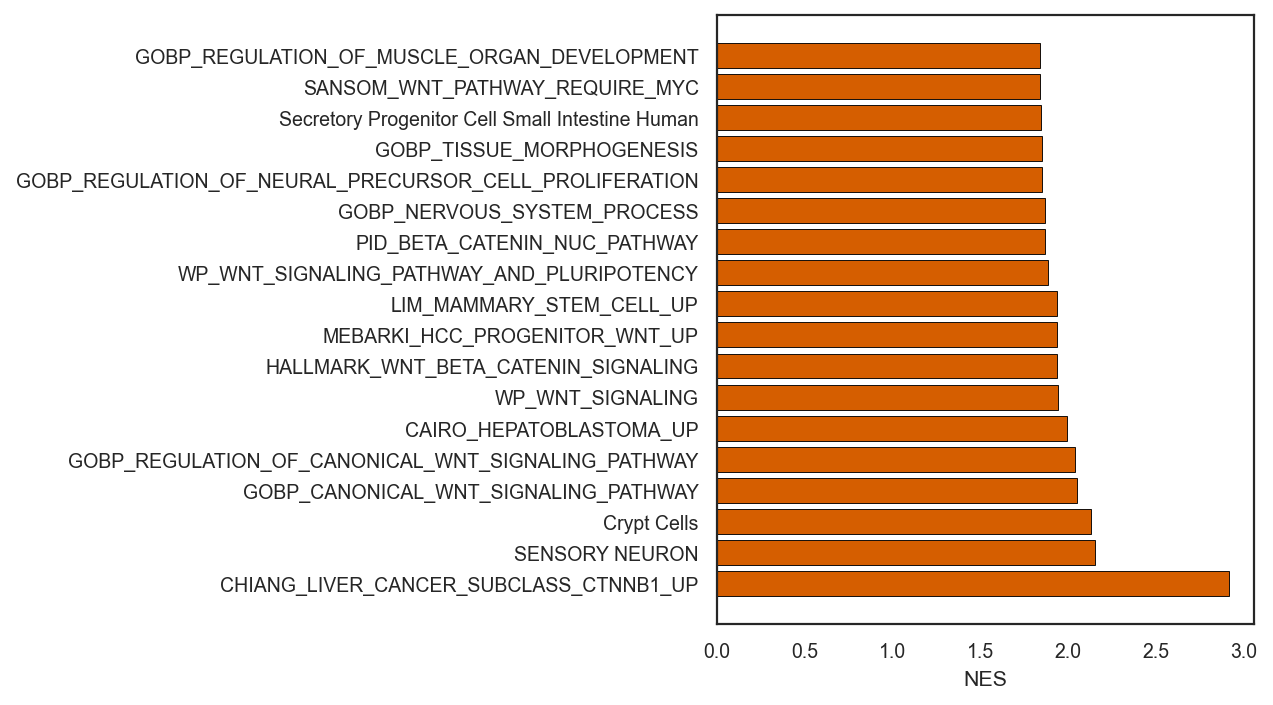

In [235]:
plot_df = selected.copy()

# 如果想保持 Excel 顺序
plot_df["Term"] = pd.Categorical(
    plot_df["Term"],
    categories=selected_terms,
    ordered=True
)

plot_df = plot_df.sort_values("Term")

plt.figure(figsize=(8, max(4, plot_df.shape[0] * 0.25)))

colors = np.where(plot_df["NES"] > 0, "#D55E00", "#0072B2")

plt.barh(
    plot_df["Term"],
    plot_df["NES"],
    color=colors,
    edgecolor="black",
    linewidth=0.4
)

plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("NES")
plt.ylabel("")
#plt.title("Resistant      Sensitive")

plt.tight_layout()
plt.savefig("NC_38030622_GSEA_selected_NES_barplot.pdf", bbox_inches="tight")
plt.show()

# 4. 方法二：定义signature high的细胞

In [280]:
epi

AnnData object with n_obs × n_vars = 10687 × 3000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Tumour_ID', 'Patient_ID', 'Response', 'Treatment', 'Week', 'sample', 'doublet_score', 'predicted_doublet', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'total_counts_hb', 'pct_counts_hb', 'total_counts_hsp', 'pct_counts_hsp', 'S_score', 'G2M_score', 'phase', 'cc.difference', 'leiden05', 'leiden02', 'leiden1', 'Bulk_resistant_score', 'Bulk_resistant_score_filt', 'label', 'Signature_group', 'cnv_score', 'CytoTRACE2_Score', 'CytoTRACE2_Potency', 'CytoTRACE2_Relative', 'preKNN_CytoTRACE2_Score', 'preKNN_CytoTRACE2_Potency', 'Bulk_resistant_score_core'
    var: 'features', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'cosg', 'hvg', 'leiden02', 'leiden02_colors', 'leiden05', 'leiden1', 'log1p', 'neighbors', 'pca', 'umap', 'leiden05_colors', 'cosg_05', 'lab

In [281]:
score_col = "Bulk_resistant_score_core"

q10 = epi.obs[score_col].quantile(0.10)
q90 = epi.obs[score_col].quantile(0.90)

epi.obs["Signature_group"] = "Intermediate"

epi.obs.loc[
    epi.obs[score_col] <= q10,
    "Signature_group"
] = "Low"

epi.obs.loc[
    epi.obs[score_col] >= q90,
    "Signature_group"
] = "High"

In [282]:
high_by_patient = (
    epi.obs
    .groupby("Patient_ID")["Signature_group"]
    .value_counts()
    .unstack(fill_value=0)
)

high_by_patient

/tmp/ipykernel_9285/1088516190.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Patient_ID")["Signature_group"]


Signature_group,High,Intermediate,Low
Patient_ID,,,
pat3,573,447,176
pat4,4,159,16
pat6,276,648,9
pat8,2,153,11
pat12,9,88,19
pat13,84,220,50
pat14,1,370,63
pat15,0,7,0
pat16,71,450,27


In [283]:
# 重新生成，避免已有 Response 列干扰
high_by_patient = (
    epi.obs
    .groupby("Patient_ID")["Signature_group"]
    .value_counts()
    .unstack(fill_value=0)
)

# 原来的计算完全不变
high_by_patient["total"] = high_by_patient.sum(axis=1)

high_by_patient["High_fraction"] = (
    high_by_patient.get("High", 0)
    / high_by_patient["total"]
)

# 最后再加 Response
high_by_patient["Response"] = (
    epi.obs.groupby("Patient_ID")["Response"].first()
)

# 排序
high_by_patient.sort_values(
    "High_fraction",
    ascending=False
)

/tmp/ipykernel_9285/1837272131.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Patient_ID")["Signature_group"]
/tmp/ipykernel_9285/1837272131.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  epi.obs.groupby("Patient_ID")["Response"].first()


Signature_group,High,Intermediate,Low,total,High_fraction,Response
Patient_ID,,,,,,
pat3,573,447,176,1196,0.479097,NonResponder
pat6,276,648,9,933,0.295820,Responder
pat13,84,220,50,354,0.237288,Responder
pat19,23,70,8,101,0.227723,Responder
pat16,71,450,27,548,0.129562,Responder
pat12,9,88,19,116,0.077586,Responder
pat31,3,34,8,45,0.066667,Responder
pat4,4,159,16,179,0.022346,Responder
pat36,23,980,100,1103,0.020852,Responder


In [167]:
patient_summary = (
    epi.obs[
        ["Patient_ID", "Response", "Signature_group"]
    ]
    .groupby(["Patient_ID", "Response"])
    ["Signature_group"]
    .apply(lambda x: (x == "High").mean())
    .reset_index(name="High_fraction")
)

patient_summary

/tmp/ipykernel_9285/3619922150.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Patient_ID", "Response"])


,Patient_ID,Response,High_fraction
0,pat3,NonResponder,0.404682
1,pat3,Responder,NaN
2,pat4,NonResponder,NaN
3,pat4,Responder,0.000000
4,pat6,NonResponder,NaN
5,pat6,Responder,0.250804
6,pat8,NonResponder,NaN
7,pat8,Responder,0.018072
8,pat12,NonResponder,NaN
9,pat12,Responder,0.103448


/tmp/ipykernel_9285/3327802694.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sc.pl.umap(epi, color=['Bulk_resistant_score','Signature_group'], cmap=plt.cm.get_cmap('magma').reversed(),vmin=0.5,


[<Axes: title={'center': 'Bulk_resistant_score'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'Signature_group'}, xlabel='UMAP1', ylabel='UMAP2'>]

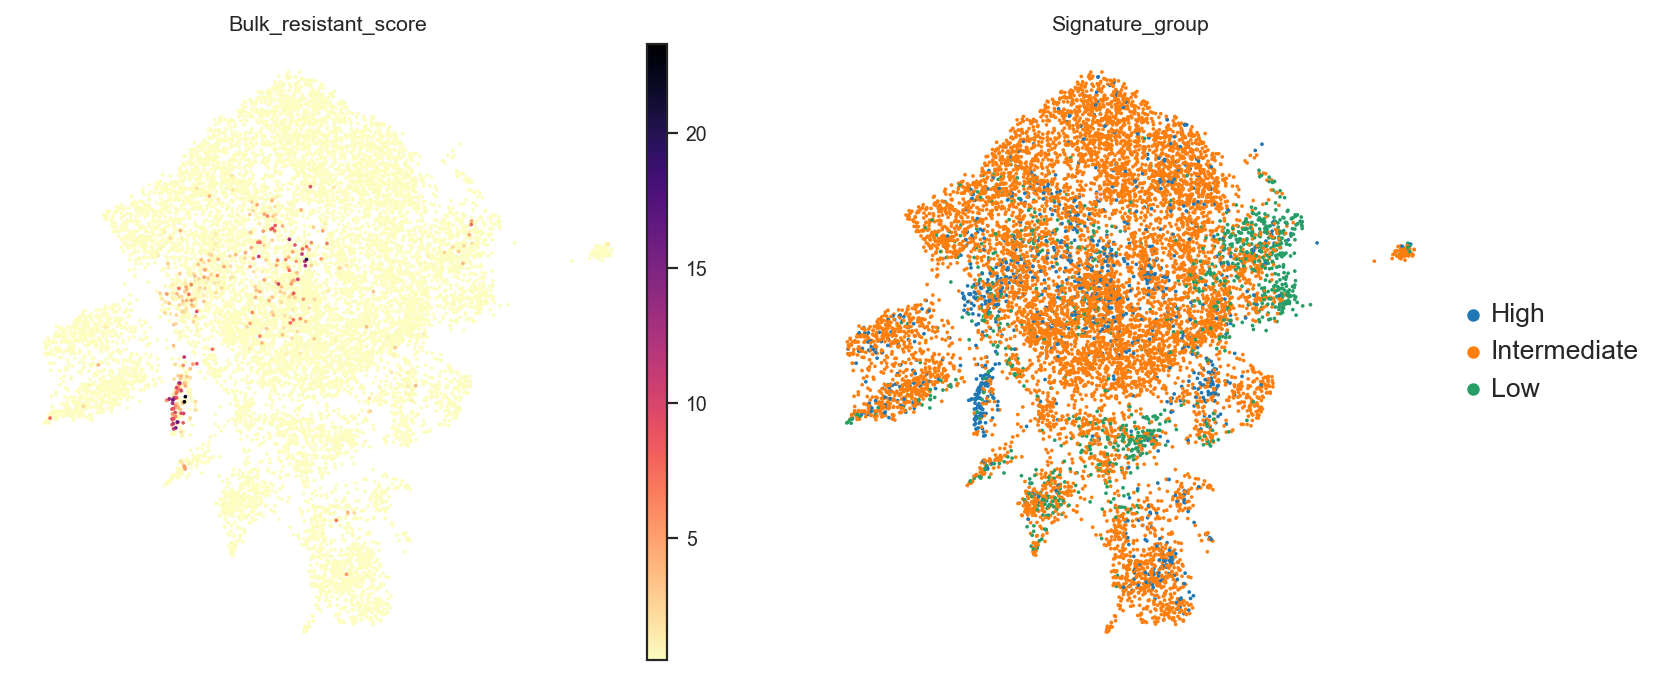

In [173]:
sc.pl.umap(epi, color=['Bulk_resistant_score','Signature_group'], cmap=plt.cm.get_cmap('magma').reversed(),vmin=0.5,  
           frameon = False, legend_fontsize=12, legend_fontoutline=1,show = False)

# 4. CytoTRACE2

In [190]:
meta = pd.read_csv("cytotrace2_metadata_chol_total.csv").set_index("cell_id")
print(meta.index.isin(epi.obs.index).mean())

1.0


In [191]:
epi.obs = epi.obs.join(meta)

In [194]:
meta = epi.obs.copy()

In [195]:
order = (
    meta.groupby("label")["CytoTRACE2_Score"]
    .mean()
    .sort_values()
    .index
)

/tmp/ipykernel_9285/261318511.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  meta.groupby("label")["CytoTRACE2_Score"]


/tmp/ipykernel_9285/1308402646.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


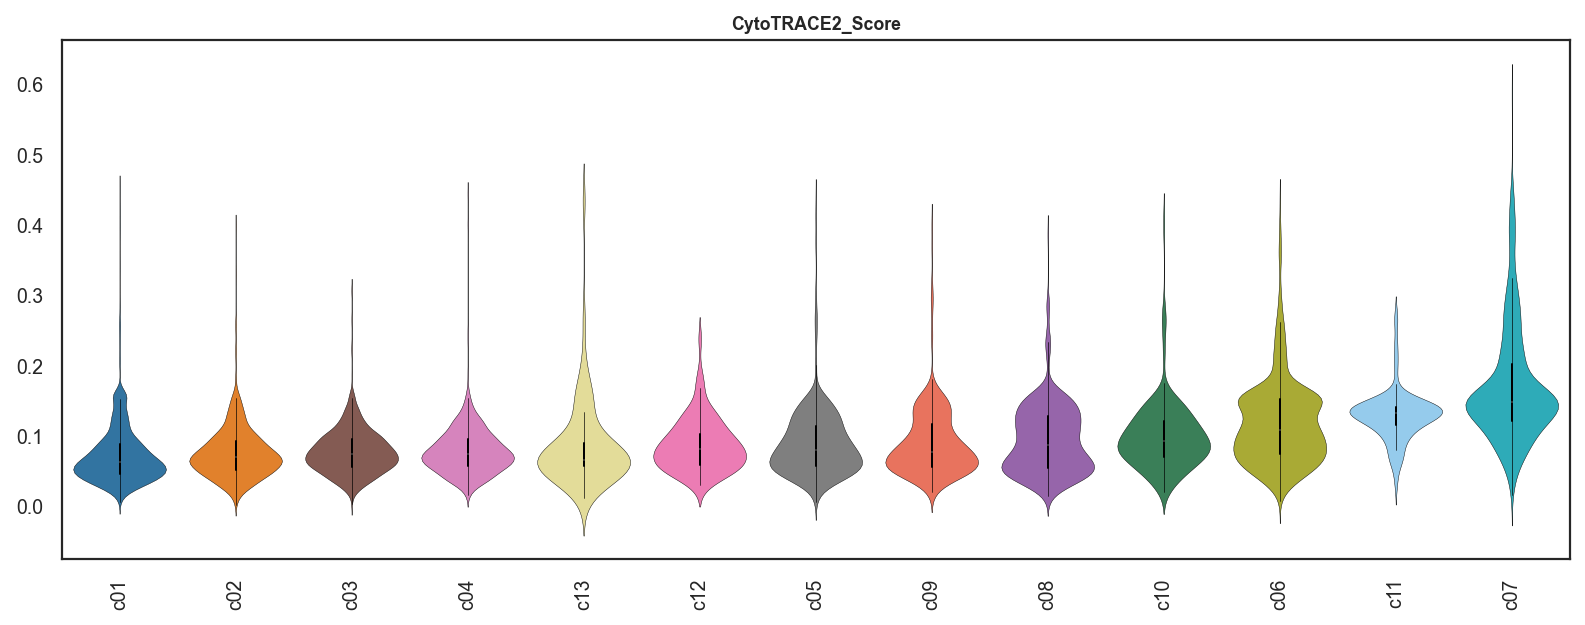

In [196]:
plt.figure(figsize=(10,4))

sns.violinplot(
    data=meta,
    x="label",
    y="CytoTRACE2_Score",
    order=order,
    palette=color_dict,
    linewidth=0.2,
    linecolor= "black"
)
plt.title('CytoTRACE2_Score', fontsize=8, fontweight='bold', pad=5)
plt.xticks(rotation=90)
plt.xlabel("")
plt.ylabel("")

plt.tight_layout()
plt.savefig('CytoTRACE2_Score_clusters.pdf', dpi=600, bbox_inches='tight')
plt.show()

/tmp/ipykernel_9285/4080559965.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_9285/4080559965.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  meta.groupby("label")["CytoTRACE2_Score"]


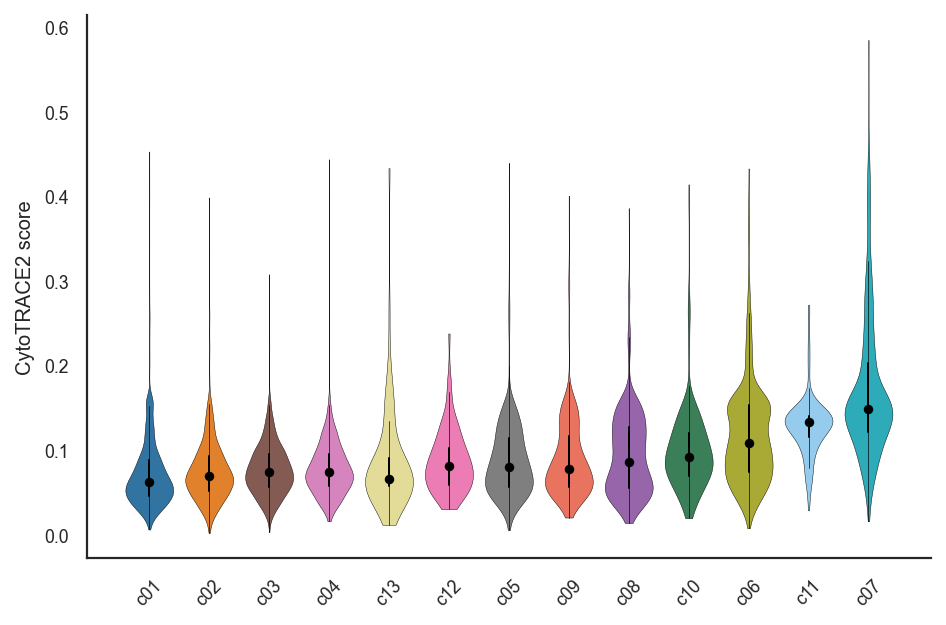

In [202]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.violinplot(
    data=meta,
    x="label",
    y="CytoTRACE2_Score",
    order=order,
    palette=color_dict,
    linewidth=0.2,
    linecolor="black",
    cut=0,
    ax=ax
)

medians = (
    meta.groupby("label")["CytoTRACE2_Score"]
    .median()
    .reindex(order)
)

for i, value in enumerate(medians):
    ax.scatter(
        i,
        value,
        color="black",
        s=12,
        zorder=5
    )

ax.set_xlabel("")
ax.set_ylabel("CytoTRACE2 score", fontsize=9)

ax.tick_params(
    axis="x",
    rotation=45,
    labelsize=8
)
ax.tick_params(
    axis="y",
    labelsize=8
)

sns.despine()

plt.tight_layout()
plt.savefig('CytoTRACE2_Score_clusters.pdf', dpi=600, bbox_inches='tight')
plt.show()

In [216]:
state_summary = (
    epi.obs
    .groupby("label", observed=True)[
        ["Bulk_resistant_score","CytoTRACE2_Score", "S_score", "G2M_score"]
    ]
    .median()
)

state_summary

,Bulk_resistant_score,CytoTRACE2_Score,S_score,G2M_score
label,,,,
c06,-0.088791,0.108899,-0.032590,-0.096333
c07,-0.137143,0.148657,0.073185,0.114333
c09,-0.491136,0.077560,-0.095548,-0.373833
c04,-0.139634,0.073927,-0.046715,-0.193083
c05,-0.643828,0.079894,-0.065386,-0.506417
c03,-0.091429,0.074157,-0.017354,-0.081167
c02,-0.071154,0.069331,-0.015184,-0.065167
c01,-0.053333,0.062524,-0.010846,-0.052000
c10,-0.381538,0.092047,-0.047774,-0.280667


In [217]:
state_z = (
    state_summary - state_summary.mean()
) / state_summary.std()

state_z

,Bulk_resistant_score,CytoTRACE2_Score,S_score,G2M_score
label,,,,
c06,-0.013804,0.769285,0.046529,0.478118
c07,-0.110947,2.285869,2.158688,1.550083
c09,-0.822151,-0.426153,-1.210660,-0.933925
c04,-0.115952,-0.564730,-0.235539,-0.014189
c05,-1.128924,-0.337107,-0.608364,-1.608567
c03,-0.019103,-0.555963,0.350770,0.555292
c02,0.021631,-0.740050,0.394086,0.636708
c01,0.057434,-0.999718,0.480718,0.703705
c10,-0.601961,0.126469,-0.256682,-0.459852


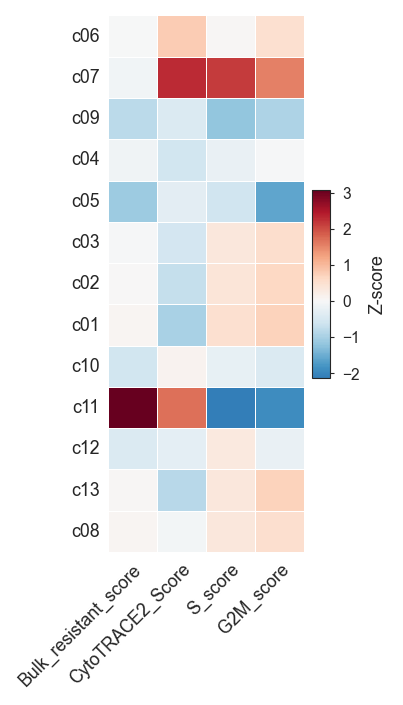

In [220]:
# =========================
# Nature-style heatmap
# =========================
fig, ax = plt.subplots(figsize=(2.5, 4.5))

hm = sns.heatmap(
    state_z,
    cmap="RdBu_r",
    center=0,

    # 格子边界尽量弱
    linewidths=0.25,
    linecolor="white",

    # colorbar
    cbar_kws={
        "label": "Z-score",
        "shrink": 0.35,      # 缩短 colorbar
        "aspect": 10,        # 更细
        "pad": 0.03
    },

    ax=ax
)

# =========================
# 坐标轴
# =========================
ax.set_xlabel("")
ax.set_ylabel("")

# X轴 45°
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha="right",
    rotation_mode="anchor",
    fontsize=8
)

# Y轴横向
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=8
)

# 去掉tick线
ax.tick_params(
    axis="both",
    length=0
)

# =========================
# Colorbar
# =========================
cbar = hm.collections[0].colorbar

cbar.ax.tick_params(
    labelsize=7,
    length=2,
    width=0.5
)

cbar.set_label(
    "Z-score",
    fontsize=8,
    labelpad=4
)

# colorbar细边框
cbar.outline.set_linewidth(0.5)

# =========================
# 输出
# =========================
plt.tight_layout()

plt.savefig(
    "CytoTRACE_cellcycle_heatmap.pdf",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

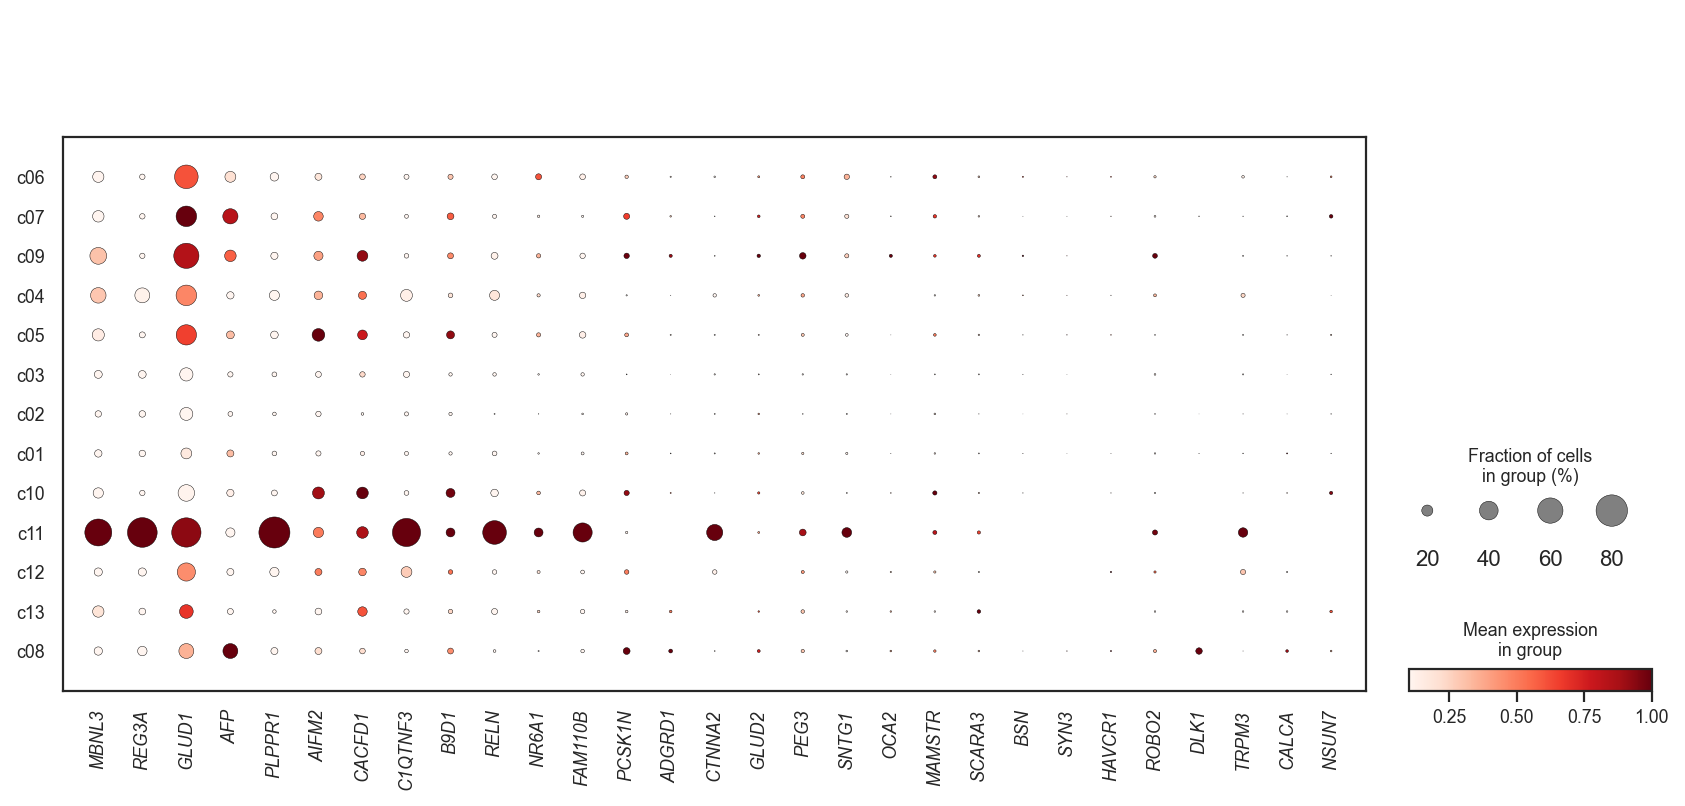

In [248]:
tmp=sc.pl.dotplot(
    epi,
    groupby="label",
    var_names= gene2,
    #figsize=(6,3),
    #dendrogram=True,
    var_group_rotation=45,
    standard_scale="var",
    return_fig=True,
    vmin = 0.1
)
# 获取所有轴对象
gene_group_ax = tmp.get_axes()['mainplot_ax']
for label in gene_group_ax.get_xticklabels():
        label.set_fontstyle('italic')
        
size_legend_ax = tmp.get_axes()['size_legend_ax']

#size_legend_ax.xaxis.label.set_fontsize(8)
for label in size_legend_ax.get_xticklabels():
   label.set_fontsize(10)
#plt.savefig('气泡图_MUC基因_病变阶段.BTC_atlas.pdf', dpi=600, bbox_inches='tight')
# 显示图表
plt.show()

In [256]:
tmphp = ad.read_h5ad("/mnt/f/HCC_VSIG4/Hepatocytes/HCC_hepatocytes_harmony_leiden(64634 × 3000__scale_log1p).h5ad")

In [259]:
from scipy import sparse

X = tmphp.raw.X

if sparse.issparse(X):
    vals = X.data
else:
    vals = np.asarray(X).ravel()

has_decimal = np.any(vals != np.round(vals))

print("dtype:", X.dtype)
print("has decimal:", has_decimal)
print("min:", vals.min())
print("max:", vals.max())

dtype: float64
has decimal: True
min: 0.40548177546930486
max: 8.78438849980298


In [260]:
tmphp

AnnData object with n_obs × n_vars = 64634 × 3000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'percent.mt', 'Cancer_type', 'clusters', 'percent.hb', 'barcodes', 'S.Score', 'G2M.Score', 'Phase', 'CC.Difference', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'total_counts_hb', 'pct_counts_hb', 'total_counts_hsp', 'pct_counts_hsp', 'leiden1', 'leiden05', 'leiden15', 'leiden2', 'leiden02'
    var: 'features', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'rb', 'hb', 'hsp', 'mt', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'dendrogram_leiden02', 'dendrogram_leiden05', 'hvg', 'leiden02', 'leiden02_colors', 

In [268]:
sc.tl.score_genes(
    tmphp,
    gene_list=gene2,
    score_name="HCC_Resistant_score",
    use_raw=True
)

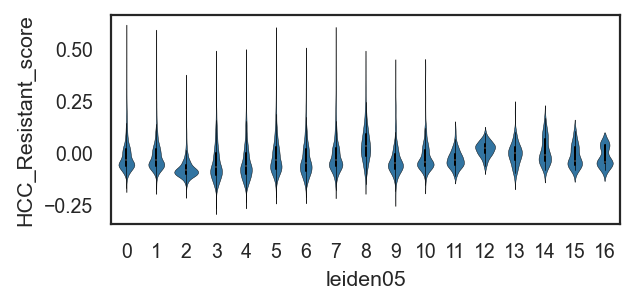

In [275]:
plt.figure(figsize=(4,2))

sns.violinplot(
    data=tmphp.obs,
    x="leiden05",
    y="HCC_Resistant_score",
    #order=order,
    #palette=color,
    linewidth=0.2,
    linecolor= "black"
)
plt.title('', fontsize=8, fontweight='bold', pad=5)
plt.xticks(rotation=0)
plt.tight_layout()
#plt.savefig('Bhattacharyya distance.pdf', dpi=600, bbox_inches='tight')
plt.show()

In [276]:
import cosg
groupby='leiden05'
cosg.cosg(
   tmphp,
   key_added='cosg',
   use_raw=False, layer='log1p', 
   mu=100,
   expressed_pct=0.1,
   remove_lowly_expressed=True,
   n_genes_user=tmphp.n_vars,
   groupby=groupby,
   return_by_group=True,
    verbosity=1 )
marker_gene=pd.DataFrame(tmphp.uns['cosg']['names'])
marker_gene.head(50)

Finished identifying marker genes by COSG, and the results are in adata.uns['cosg'].


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,SLC22A1,RIDA,CD3E,GOLGA8B,EDN1,SPC25,KRT19,C1QC,ANKFN1,CLEC14A,MZB1,MTRNR2L1,FCGR2B,PPP1R3A,PAGE1,IFI30,PLK1
1,APCS,HPD,CD2,MLXIPL,CXCL6,RRM2,SPINT2,MS4A7,KLK4,FCN3,JCHAIN,ZNF385D,RP1,VCX3B,BPIFB2,SCD,SCD
2,HP,ARG1,TRAC,AC011498.4,MMP7,PBK,FXYD3,IGSF6,MATN3,EMCN,IGHG1,RHBG,PCSK1N,TNP1,PLA2G2A,TIMP3,TNFRSF11B
3,APOA5,ALDOB,CD3G,PLIN5,TACSTD2,PCLAF,EPCAM,MS4A4A,MYH7B,ECSCR,IGHG4,SELE,MT1H,VCX,TAGLN,ASPM,C9
4,ORM1,GSTA2,TRBC2,LPIN3,CXCL1,CDK1,BICC1,FOLR2,HEPN1,PLVAP,IGHG3,CYP3A4,C6orf141,PAGE5,CYP3A7,HPGD,YBX3
5,LECT2,GSTA1,CD3D,RNPC3,CLDN4,CDCA3,CD24,MSR1,HEPACAM,FLT1,IGLC3,XPNPEP2,TERT,VCAM1,PLA2G1B,A2M,ABCA1
6,UGT2B4,ADH1C,IL7R,NRBP2,CREB5,NCAPG,KRT7,CSF1R,ACTN2,RAMP3,CD79A,GADD45G,MT1M,TRIM6,SPINT2,LY6K,NNMT
7,AZGP1,DCXR,LCK,SLC6A1,SOX4,UBE2C,LGALS3,VSIG4,CH25H,CALCRL,IGHA1,LMOD1,SCGN,PAGE2,CHI3L1,YBX3,FADS1
8,FGG,GNMT,ACAP1,CCNL2,TGFB2,HJURP,S100A14,MS4A6A,SPARCL1,SOX18,IGLC2,CYP2B6,FBN1,RBP2,CRP,NNMT,FDPS
9,FGB,ASS1,CD52,PABPC1L,TCIM,ZWINT,KRT23,CYBB,ODAM,GNG11,IGHM,RGS16,MT1A,VCX3A,TSPAN8,MICAL3,A2M


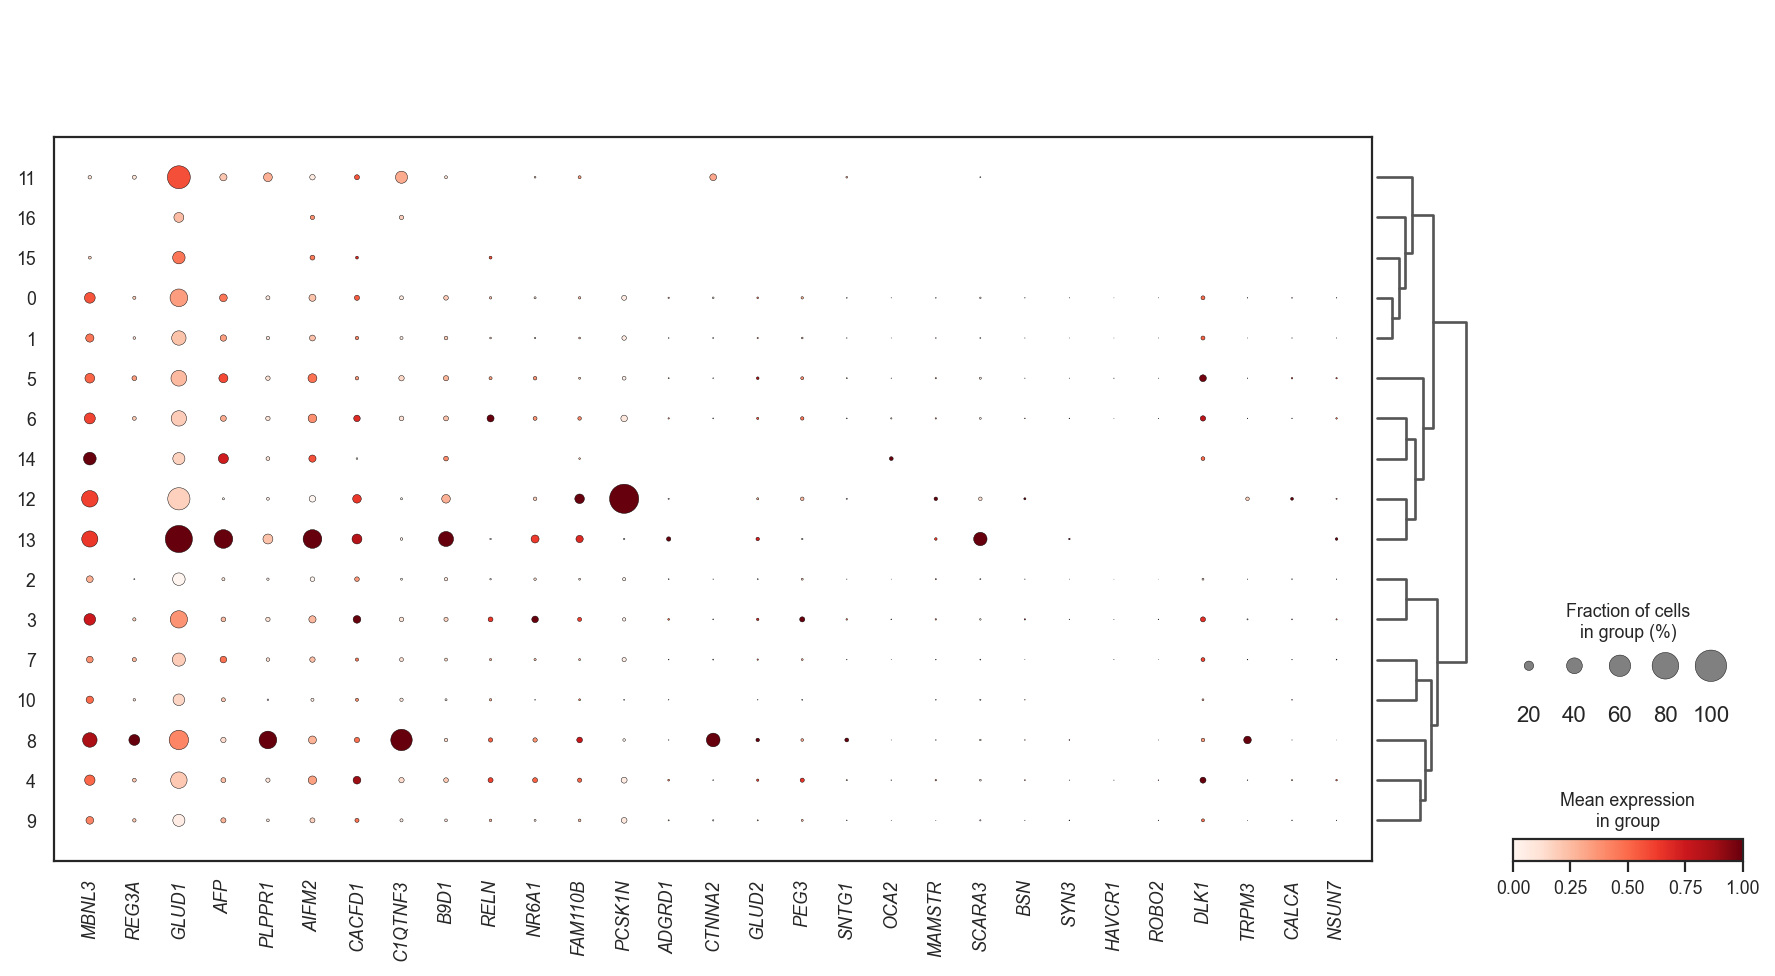

In [265]:
tmp=sc.pl.dotplot(
    tmphp,
    groupby="leiden05",
    var_names= gene2,
    #figsize=(6,3),
    dendrogram=True,
    var_group_rotation=45,
    standard_scale="var",
    return_fig=True
)
# 获取所有轴对象
gene_group_ax = tmp.get_axes()['mainplot_ax']
for label in gene_group_ax.get_xticklabels():
        label.set_fontstyle('italic')
        
size_legend_ax = tmp.get_axes()['size_legend_ax']

#size_legend_ax.xaxis.label.set_fontsize(8)
for label in size_legend_ax.get_xticklabels():
   label.set_fontsize(10)
#plt.savefig('气泡图_MUC基因_病变阶段.BTC_atlas.pdf', dpi=600, bbox_inches='tight')
# 显示图表
plt.show()

In [267]:
print(tmphp.obs['leiden05'].value_counts())

leiden05
0     16630
1     10756
2      7781
3      7712
4      7710
5      6247
6      3513
7      1850
8       894
9       858
10      373
11       93
12       73
13       56
14       50
15       24
16       14
Name: count, dtype: int64


<Axes: title={'center': 'Leiden = 1.0'}, xlabel='UMAP1', ylabel='UMAP2'>

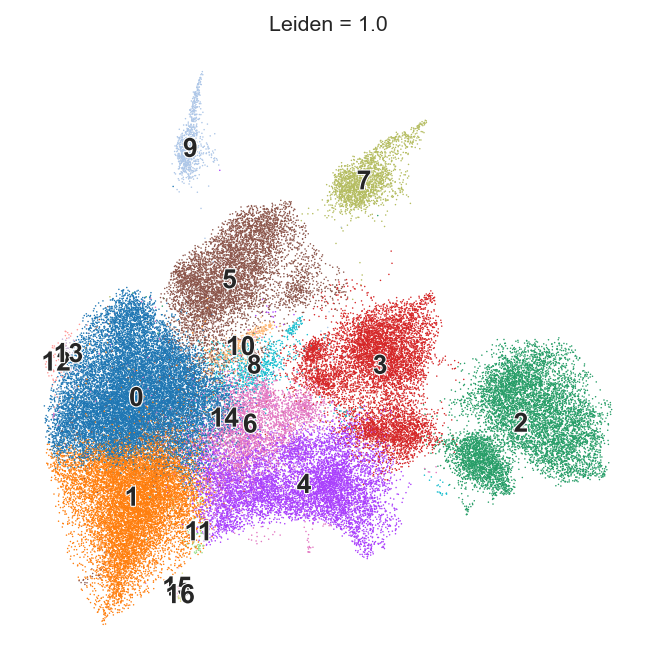

In [266]:
sc.pl.umap(tmphp, color=['leiden05'], legend_loc='on data',title='Leiden = 1.0', frameon = False, legend_fontsize=12, legend_fontoutline=1,show = False)
#plt.savefig('a.pdf', dpi=600, bbox_inches='tight')